In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\vamsh\Downloads\UserData (2) - UserData (2).csv")
df

,PreferredSponsors,Gender,Country,Degree,Sign Up Date,city,zip,isFromSocialMedia
0,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,Nigeria,Undergraduate Student,2023-07-23T08:05:58.602Z,Owerri,460103,False
1,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,India,Undergraduate Student,2023-04-24T09:57:07.405Z,kottayam,686501,False
2,"[""GlobalShala"",""Illinois Institute of Technolo...",NaN,India,NaN,2022-10-14T17:13:36.303Z,NaN,NaN,False
3,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",NaN,Albania,NaN,2023-06-06T12:29:01.772Z,NaN,NaN,True
4,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Female,Ghana,Not in Education,2023-06-15T16:31:42.719Z,Kumasi,AT-1214-9090,False
...,...,...,...,...,...,...,...,...
27557,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Female,Botswana,Undergraduate Student,2023-04-08T05:30:44.705Z,Gaborone,123456,True
27558,"[""GlobalShala"",""Saint Louis University"",""Illin...",Male,United States,Undergraduate Student,2023-02-01T20:46:32.637Z,Coppell,75019,False
27559,"[""GlobalShala"",""Illinois Institute of Technolo...",Male,United States,High School Student,2022-09-22T14:06:56.114Z,Austin,78727,False
27560,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,Pakistan,NaN,2023-06-16T04:18:38.811Z,Daraban kalan,29111,True


In [3]:
df.shape

(27562, 8)

In [4]:
df.head()

,PreferredSponsors,Gender,Country,Degree,Sign Up Date,city,zip,isFromSocialMedia
0,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,Nigeria,Undergraduate Student,2023-07-23T08:05:58.602Z,Owerri,460103,False
1,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,India,Undergraduate Student,2023-04-24T09:57:07.405Z,kottayam,686501,False
2,"[""GlobalShala"",""Illinois Institute of Technolo...",NaN,India,NaN,2022-10-14T17:13:36.303Z,NaN,NaN,False
3,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",NaN,Albania,NaN,2023-06-06T12:29:01.772Z,NaN,NaN,True
4,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Female,Ghana,Not in Education,2023-06-15T16:31:42.719Z,Kumasi,AT-1214-9090,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27562 entries, 0 to 27561
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   PreferredSponsors  27562 non-null  object
 1   Gender             18027 non-null  object
 2   Country            27500 non-null  object
 3   Degree             16750 non-null  object
 4   Sign Up Date       27562 non-null  object
 5   city               18028 non-null  object
 6   zip                18018 non-null  object
 7   isFromSocialMedia  27553 non-null  object
dtypes: object(8)
memory usage: 1.7+ MB


In [6]:
df.describe()

,PreferredSponsors,Gender,Country,Degree,Sign Up Date,city,zip,isFromSocialMedia
count,27562,18027,27500,16750,27562,18028,18018,27553
unique,94,4,169,4,27561,4727,7453,2
top,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,India,Undergraduate Student,2022-10-30T17:25:54.072Z,Hyderabad,63108,True
freq,22011,11027,11893,6527,2,743,629,13811


In [7]:
df.isnull().sum()

PreferredSponsors        0
Gender                9535
Country                 62
Degree               10812
Sign Up Date             0
city                  9534
zip                   9544
isFromSocialMedia        9
dtype: int64

In [8]:
 df = df.dropna(subset=['Country'])

In [9]:
df['Degree']=df['Degree'].fillna('Not mentioned').replace('null','Not mentioned')
df['Degree'].unique()

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2444466804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Degree']=df['Degree'].fillna('Not mentioned').replace('null','Not mentioned')


array(['Undergraduate Student', 'Not mentioned', 'Not in Education',
       'High School Student', 'Graduate Program Student'], dtype=object)

In [10]:
df['Gender'].unique()

array(['Male', nan, 'Female', 'Other', "Don't want to specify"],
      dtype=object)

In [11]:
df['Gender']=df['Gender'].fillna('Not mentioned')
df['Gender'].unique()

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2543438507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender']=df['Gender'].fillna('Not mentioned')


array(['Male', 'Not mentioned', 'Female', 'Other',
       "Don't want to specify"], dtype=object)

In [12]:
df['isFromSocialMedia']=df['isFromSocialMedia'].replace('null', np.nan).fillna(df['isFromSocialMedia'].mode()[0])
df['isFromSocialMedia'].unique()

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2280656979.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['isFromSocialMedia']=df['isFromSocialMedia'].replace('null', np.nan).fillna(df['isFromSocialMedia'].mode()[0])
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2280656979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['isFromSocialMedia']=df['isFromSocialMedia'].replace('null', np.nan).fillna(df['isFromSocialMedia'].mode()[0])


array([False,  True])

In [13]:
df.isnull().sum()

PreferredSponsors       0
Gender                  0
Country                 0
Degree                  0
Sign Up Date            0
city                 9472
zip                  9482
isFromSocialMedia       0
dtype: int64

In [14]:
# Step 1: Apply the mode directly to the "city" and "zipcode" columns grouped by "Country"
df['city'] = df.groupby('Country')['city'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Not mentioned'))
df['zip'] = df.groupby('Country')['zip'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Not mentioned'))

# Verify if missing values are handled
print(df.isnull().sum())


PreferredSponsors    0
Gender               0
Country              0
Degree               0
Sign Up Date         0
city                 0
zip                  0
isFromSocialMedia    0
dtype: int64


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\1169167602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['city'] = df.groupby('Country')['city'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Not mentioned'))
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\1169167602.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['zip'] = df.groupby('Country')['zip'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Not mentioned'))


In [15]:
df.shape

(27500, 8)

In [64]:
df.duplicated().sum()


0

In [ ]:
#if any duplicates were present and to remove them
#df = df.drop_duplicates()
#print(f"Shape after removing duplicates: {df_no_duplicates.shape}")

In [16]:
df['Sign Up Date'] = pd.to_datetime(df['Sign Up Date'])
#df['Sign Up Date'].head()
# Extract only the date part (without time)
df['Sign Up Date'] = df['Sign Up Date'].dt.date

# Display the first few entries
print(df['Sign Up Date'].head())

0    2023-07-23
1    2023-04-24
2    2022-10-14
3    2023-06-06
4    2023-06-15
Name: Sign Up Date, dtype: object


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\223654647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sign Up Date'] = pd.to_datetime(df['Sign Up Date'])
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\223654647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sign Up Date'] = df['Sign Up Date'].dt.date


In [17]:
for column in df.columns:
    print(f"\nColumn: {column}")
    print(f"Data type: {df[column].dtype}")
    print(f"Number of unique values: {df[column].nunique()}")
    print(f"Number of missing values: {df[column].isnull().sum()}")
    if df[column].dtype == 'object':
        print("Top 5 most common values:")
        print(df[column].value_counts().head())
    else:
        print("Descriptive statistics:")
        print(df[column].describe())
    print("-" * 50)


Column: PreferredSponsors
Data type: object
Number of unique values: 94
Number of missing values: 0
Top 5 most common values:
PreferredSponsors
["GlobalShala","Grant Thornton China","Saint Louis University","Illinois Institute of Technology","Excelerate"]    22011
["GlobalShala","Illinois Institute of Technology","Saint Louis University","Grant Thornton China","Excelerate"]     1807
["Illinois Institute of Technology","Grant Thornton China","Excelerate"]                                            1230
["Saint Louis University"]                                                                                           607
["GlobalShala","Saint Louis University","Illinois Institute of Technology","Grant Thornton China","Excelerate"]      389
Name: count, dtype: int64
--------------------------------------------------

Column: Gender
Data type: object
Number of unique values: 5
Number of missing values: 0
Top 5 most common values:
Gender
Male                     11027
Not mentioned       

In [18]:
df['isFromSocialMedia'].value_counts().head()

isFromSocialMedia
True     13820
False    13680
Name: count, dtype: int64

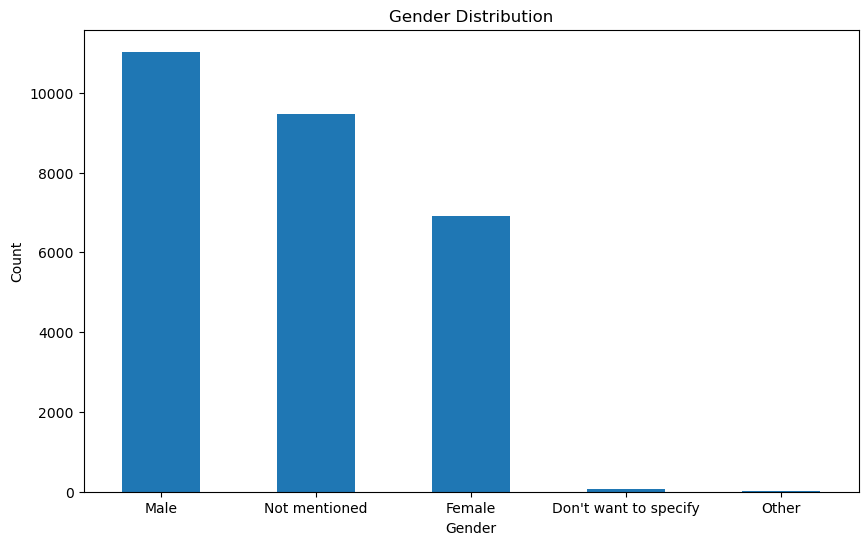

Gender Distribution Counts:
Gender
Male                     11027
Not mentioned             9473
Female                    6910
Don't want to specify       75
Other                       15
Name: count, dtype: int64


In [71]:
plt.figure(figsize=(10, 6))
gender_counts = df['Gender'].value_counts()
gender_counts.plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels if needed
plt.show()

# Print the counts below the plot
print("Gender Distribution Counts:")
print(gender_counts)


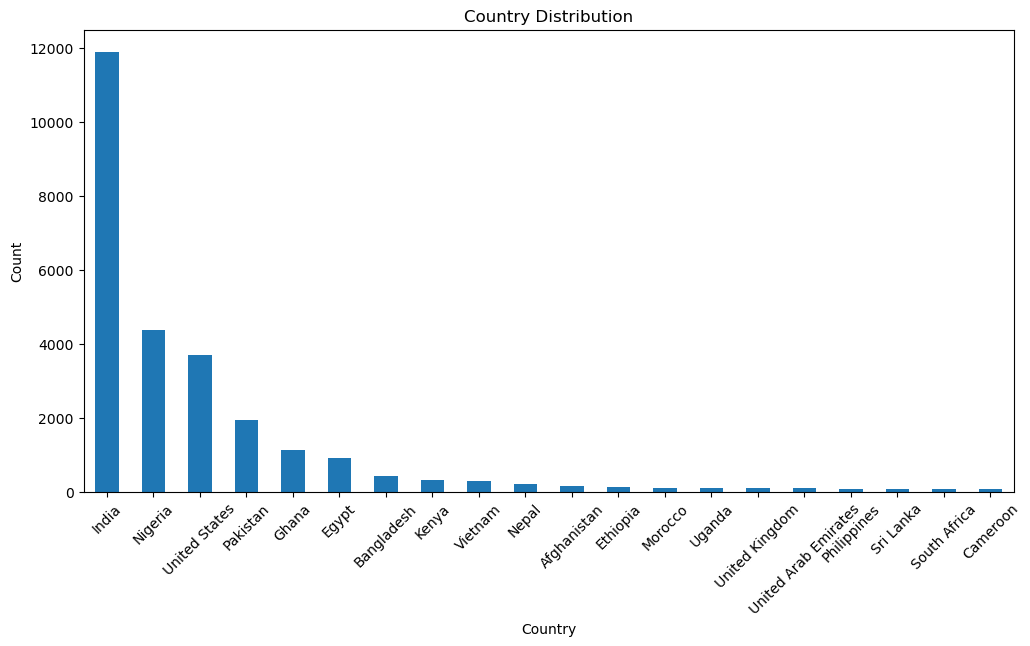

Top 20 Country Distribution Counts:
Country
India                   11893
Nigeria                  4357
United States            3691
Pakistan                 1928
Ghana                    1124
Egypt                     897
Bangladesh                422
Kenya                     302
Vietnam                   290
Nepal                     193
Afghanistan               147
Ethiopia                  123
Morocco                   107
Uganda                    101
United Kingdom             83
United Arab Emirates       83
Philippines                80
Sri Lanka                  78
South Africa               75
Cameroon                   69
Name: count, dtype: int64


In [72]:
plt.figure(figsize=(12, 6))
country_counts = df['Country'].value_counts().head(20)  # Get the top 20 countries
country_counts.plot(kind='bar')

plt.title('Country Distribution')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Print the counts below the plot
print("Top 20 Country Distribution Counts:")
print(country_counts)


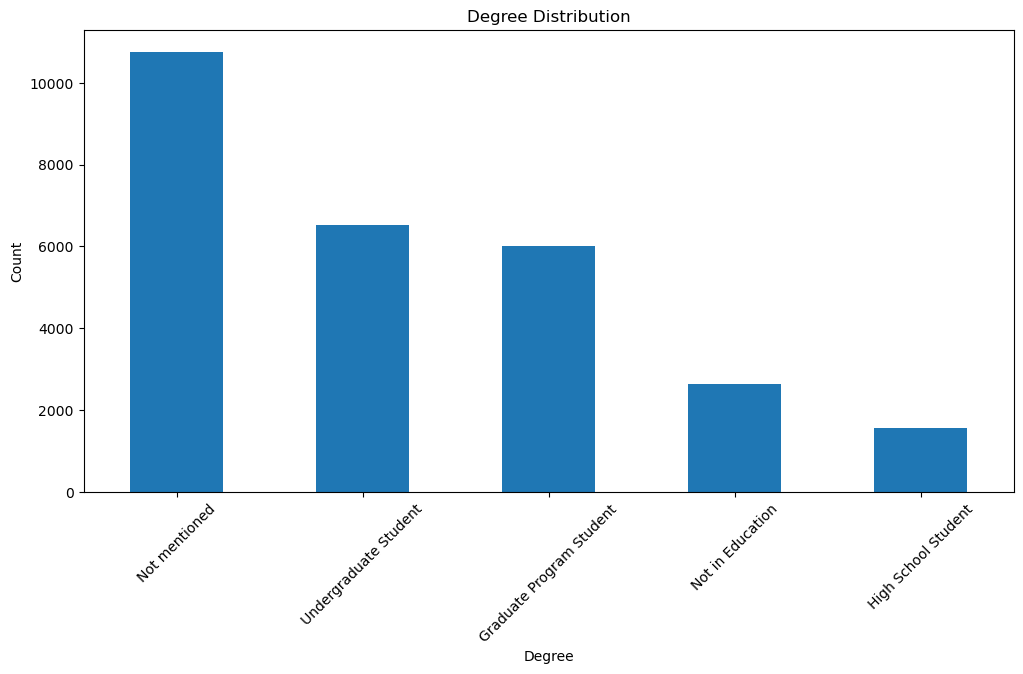

Degree Distribution Counts:
Degree
Not mentioned               10750
Undergraduate Student        6527
Graduate Program Student     6015
Not in Education             2646
High School Student          1562
Name: count, dtype: int64


In [73]:
plt.figure(figsize=(12, 6))
degree_counts = df['Degree'].value_counts()  # Get counts of all degrees
degree_counts.plot(kind='bar')

plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Print the counts below the plot
print("Degree Distribution Counts:")
print(degree_counts)


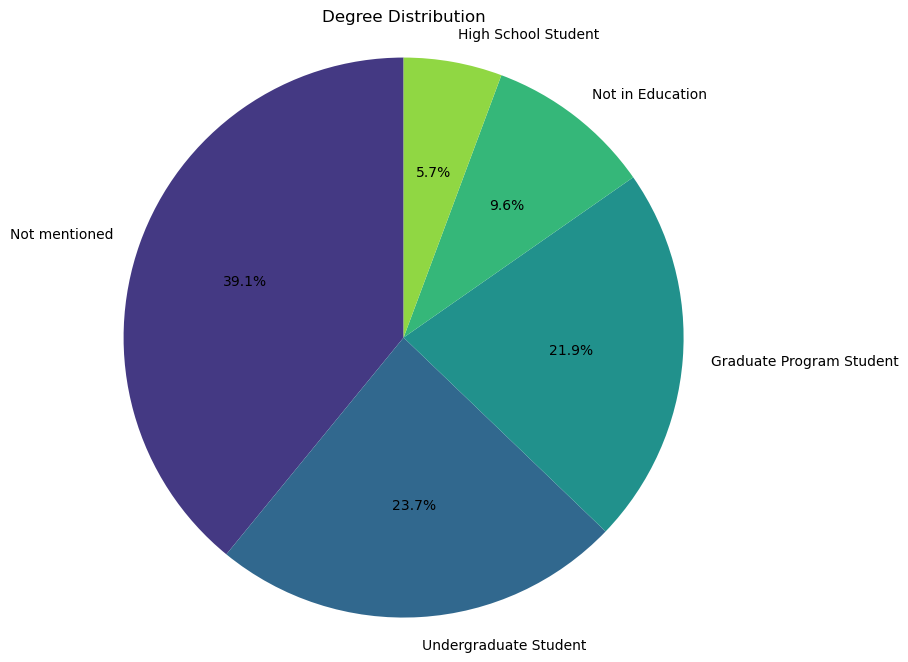

Degree Counts:
Degree
Not mentioned               10750
Undergraduate Student        6527
Graduate Program Student     6015
Not in Education             2646
High School Student          1562
Name: count, dtype: int64


In [77]:
# Degree Distribution Pie Chart
plt.figure(figsize=(10, 8))
degree_counts = df['Degree'].value_counts()
degree_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(degree_counts)))
plt.title('Degree Distribution')
plt.ylabel('')  # Hides the y-label
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Optional: Print the counts for each degree
print("Degree Counts:")
print(degree_counts)


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\507193324.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sign Up Date'] = pd.to_datetime(df['Sign Up Date'])


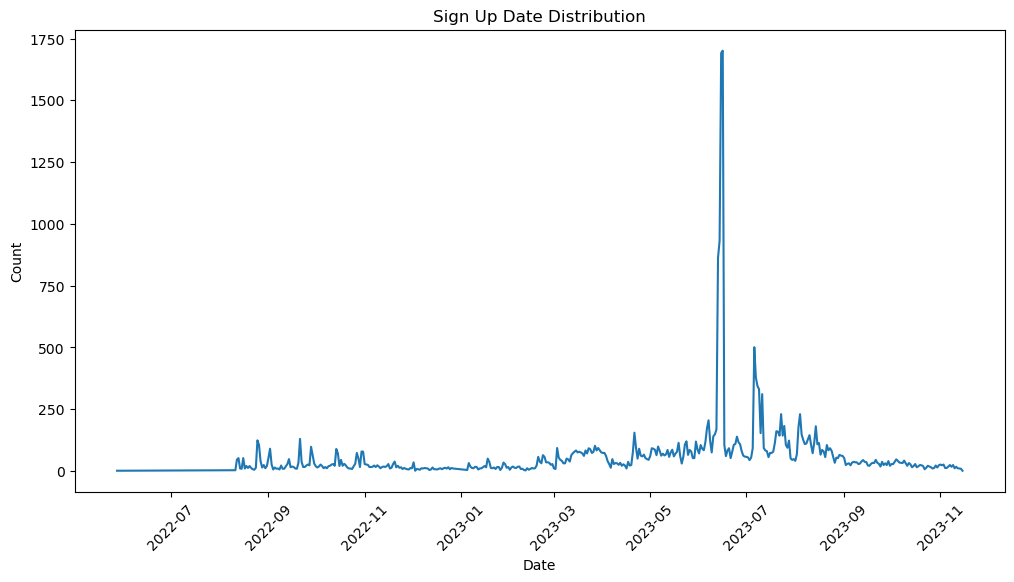

Sign Up Date Counts:
Sign Up Date
2022-05-28     1
2022-05-31     1
2022-08-10     3
2022-08-11     3
2022-08-12    46
              ..
2023-11-11    17
2023-11-12    11
2023-11-13    10
2023-11-14     9
2023-11-15     1
Name: count, Length: 457, dtype: int64


In [74]:
# Sign Up Date Analysis
# Ensure the Sign Up Date is in datetime format
df['Sign Up Date'] = pd.to_datetime(df['Sign Up Date'])

# Count the occurrences of each sign-up date and sort them
signup_counts = df['Sign Up Date'].dt.date.value_counts().sort_index()

# Plotting the sign-up date distribution
plt.figure(figsize=(12, 6))
signup_counts.plot(kind='line')
plt.title('Sign Up Date Distribution')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Print the counts below the plot
print("Sign Up Date Counts:")
print(signup_counts)


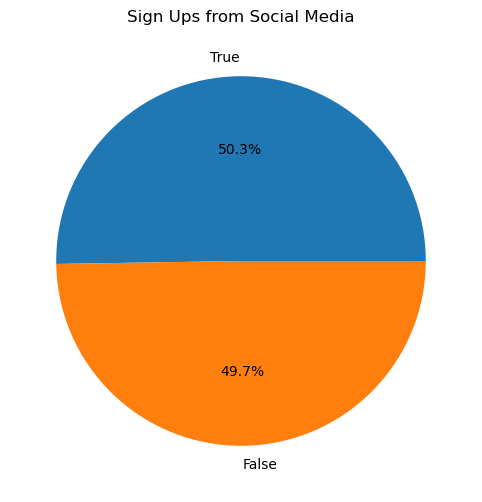

In [23]:
# Social Media Distribution
plt.figure(figsize=(8, 6))
df['isFromSocialMedia'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sign Ups from Social Media')
plt.ylabel('')
plt.show()

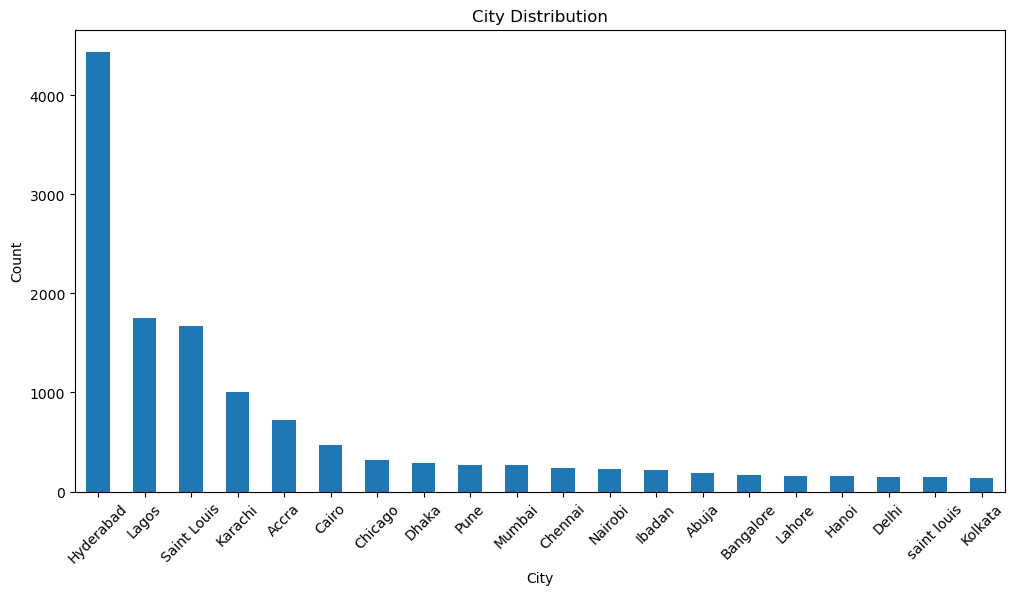

Top 20 City Counts:
city
Hyderabad      4441
Lagos          1747
Saint Louis    1667
Karachi        1002
Accra           723
Cairo           474
Chicago         318
Dhaka           292
Pune            268
Mumbai          265
Chennai         241
Nairobi         231
Ibadan          219
Abuja           191
Bangalore       168
Lahore          154
Hanoi           154
Delhi           148
saint louis     146
Kolkata         136
Name: count, dtype: int64


In [75]:
# Country Distribution
# Count the occurrences of each city and get the top 20
city_counts = df['city'].value_counts().head(20)

# Plotting the city distribution
plt.figure(figsize=(12, 6))
city_counts.plot(kind='bar')
plt.title('City Distribution')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Print the counts below the plot
print("Top 20 City Counts:")
print(city_counts)


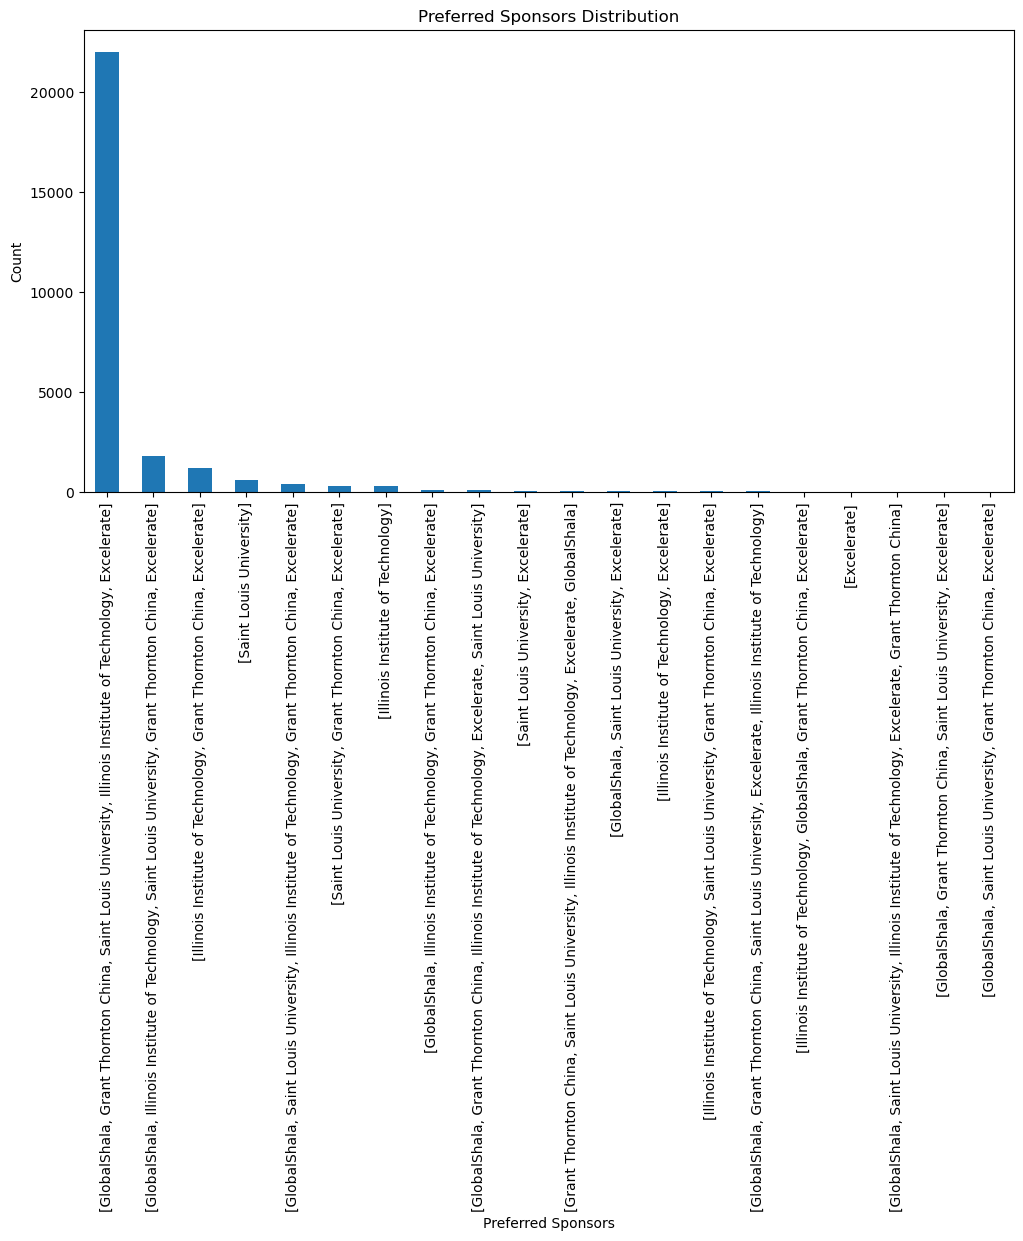

Top 20 Preferred Sponsors Counts:
PreferredSponsors
[GlobalShala, Grant Thornton China, Saint Louis University, Illinois Institute of Technology, Excelerate]    22011
[GlobalShala, Illinois Institute of Technology, Saint Louis University, Grant Thornton China, Excelerate]     1807
[Illinois Institute of Technology, Grant Thornton China, Excelerate]                                          1230
[Saint Louis University]                                                                                       607
[GlobalShala, Saint Louis University, Illinois Institute of Technology, Grant Thornton China, Excelerate]      389
[Saint Louis University, Grant Thornton China, Excelerate]                                                     321
[Illinois Institute of Technology]                                                                             297
[GlobalShala, Illinois Institute of Technology, Grant Thornton China, Excelerate]                              105
[GlobalShala, Grant Thornton

In [76]:
# Country Distribution
# Count the occurrences of each preferred sponsor and get the top 20
preferred_sponsor_counts = df['PreferredSponsors'].value_counts().head(20)

# Plotting the preferred sponsors distribution
plt.figure(figsize=(12, 6))
preferred_sponsor_counts.plot(kind='bar')
plt.title('Preferred Sponsors Distribution')
plt.xlabel('Preferred Sponsors')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

# Print the counts below the plot
print("Top 20 Preferred Sponsors Counts:")
print(preferred_sponsor_counts)


In [83]:
df['PreferredSponsors'].head(5)

0    ["GlobalShala","Grant Thornton China","Saint L...
1    ["GlobalShala","Grant Thornton China","Saint L...
2    ["GlobalShala","Illinois Institute of Technolo...
3    ["GlobalShala","Grant Thornton China","Saint L...
4    ["GlobalShala","Grant Thornton China","Saint L...
Name: PreferredSponsors, dtype: object

In [26]:
# Convert the column values from strings to actual lists
df_cleaned=df
df_cleaned['PreferredSponsors'] = df['PreferredSponsors'].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Flatten the list of sponsors
all_sponsors = df_cleaned['PreferredSponsors'].explode()

# Count the occurrences of each sponsor
top_20_sponsors = all_sponsors.value_counts().head(20)

# Display the top 20 sponsors
print(top_20_sponsors)


PreferredSponsors
Excelerate                          26571
Illinois Institute of Technology    26321
Grant Thornton China                26320
Saint Louis University              25709
GlobalShala                         24817
Name: count, dtype: int64


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\4107402637.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['PreferredSponsors'] = df['PreferredSponsors'].apply(lambda x: eval(x) if isinstance(x, str) else [])


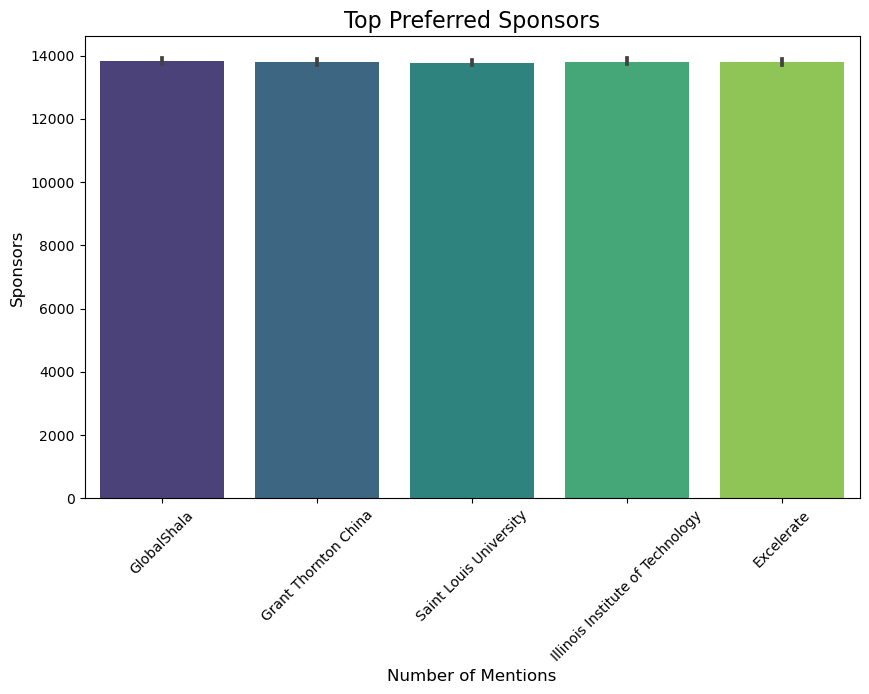

In [27]:
# Plotting the top 20 sponsors
plt.figure(figsize=(10, 6))
sns.barplot(x=all_sponsors.values, y=all_sponsors.index, palette='viridis')
plt.title('Top Preferred Sponsors', fontsize=16)
plt.xlabel('Number of Mentions', fontsize=12)
plt.ylabel('Sponsors', fontsize=12)
plt.xticks(rotation=45)
plt.show()

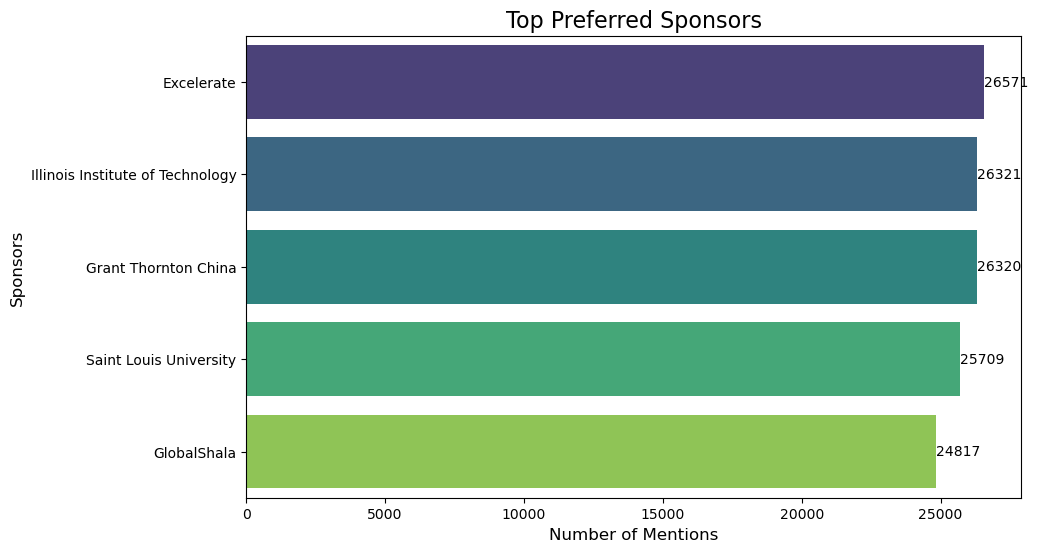

In [28]:
# Plotting the top 20 sponsors
plt.figure(figsize=(10, 6))
sns_bar = sns.barplot(x=top_20_sponsors.values, y=top_20_sponsors.index, palette='viridis')

# Add counts on top of the bars
for index, value in enumerate(top_20_sponsors.values):
    plt.text(value + 1, index, str(value), va='center')

# Set the labels and title
plt.title('Top Preferred Sponsors', fontsize=16)
plt.xlabel('Number of Mentions', fontsize=12)
plt.ylabel('Sponsors', fontsize=12)

# Rotate x-axis labels for better readability
#plt.xticks(rotation=45)

# Show the plot
plt.show()

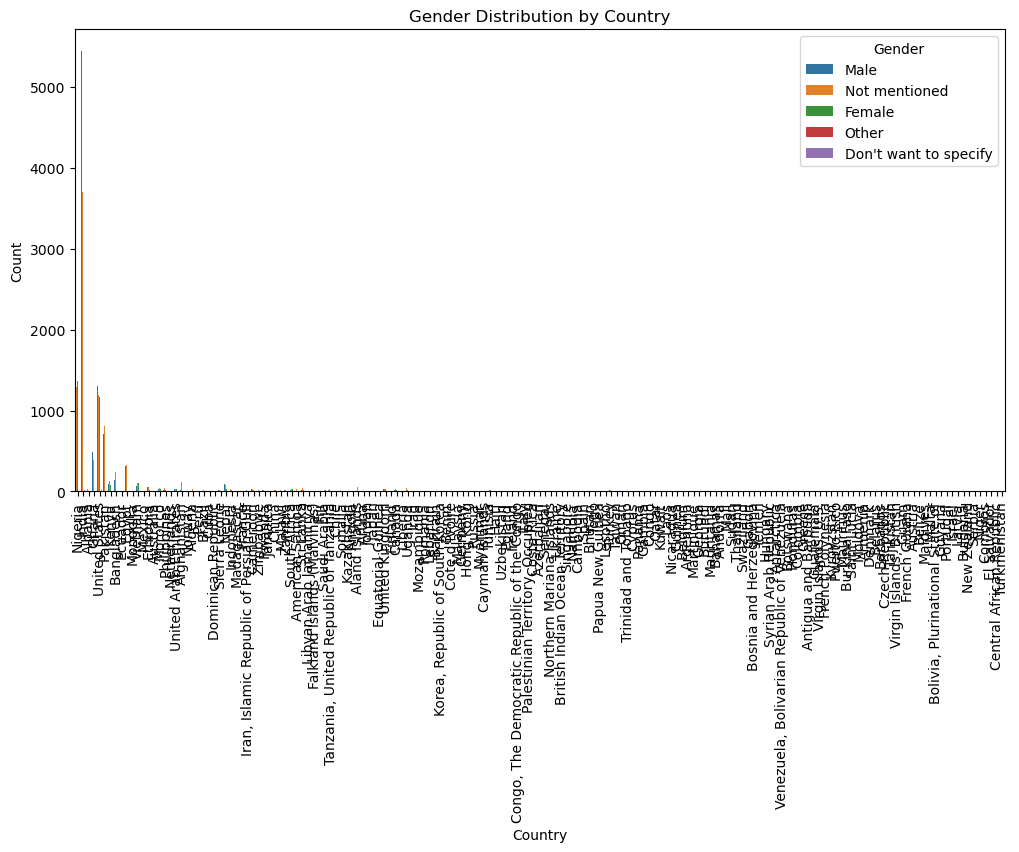

In [29]:

# Gender vs Country
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Gender', data=df)
plt.title('Gender Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Gender')
plt.show()

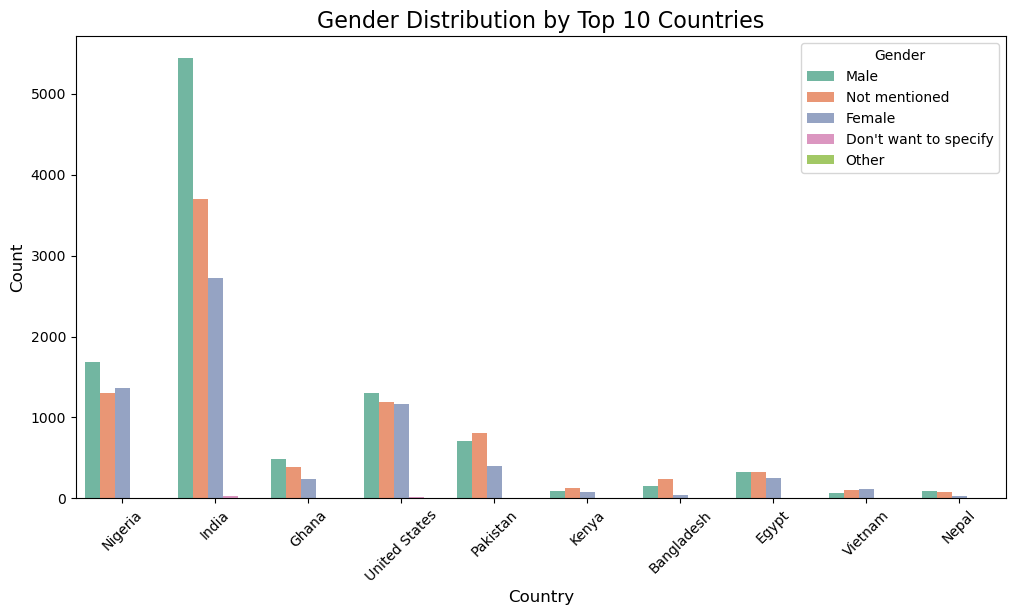

Country
India            11893
Nigeria           4357
United States     3691
Pakistan          1928
Ghana             1124
Egypt              897
Bangladesh         422
Kenya              302
Vietnam            290
Nepal              193
Name: count, dtype: int64


In [31]:
# Find the top 10 countries by total count
top_10_countries = df['Country'].value_counts().head(10).index

# Filter the dataframe for only the top 10 countries
df_top_10 = df[df['Country'].isin(top_10_countries)]

# Plot Gender Distribution by Country (for top 10 countries)
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Gender', data=df_top_10, palette='Set2')
plt.title('Gender Distribution by Top 10 Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

print(df_top_10['Country'].value_counts())

AttributeError: 'numpy.bool_' object has no attribute 'startswith'

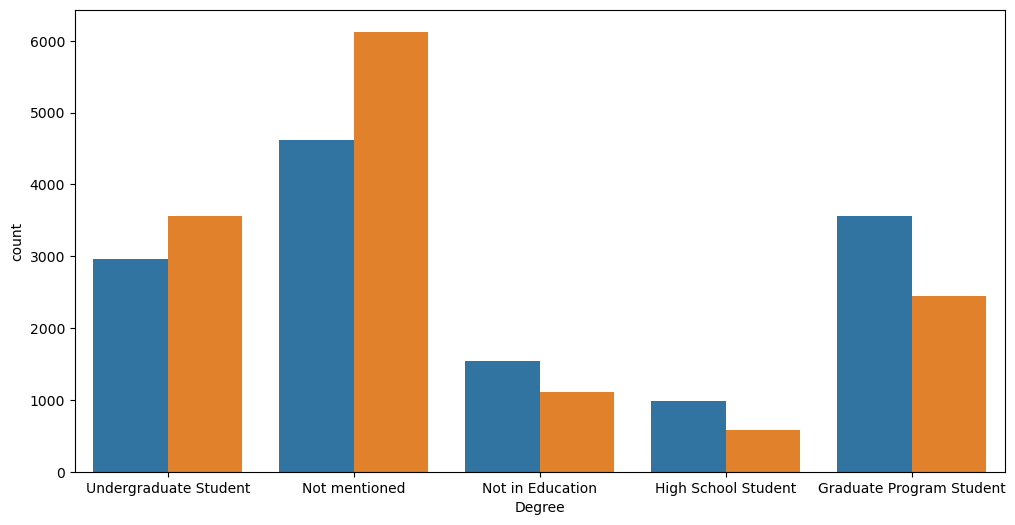

In [34]:
# Degree vs isFromSocialMedia
plt.figure(figsize=(12, 6))
sns.countplot(x='Degree', hue='isFromSocialMedia', data=df)
plt.title('Degree Distribution by Social Media Sign Up')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='From Social Media')
plt.show()

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\1370767706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['isFromSocialMedia'] = df['isFromSocialMedia'].astype(str)


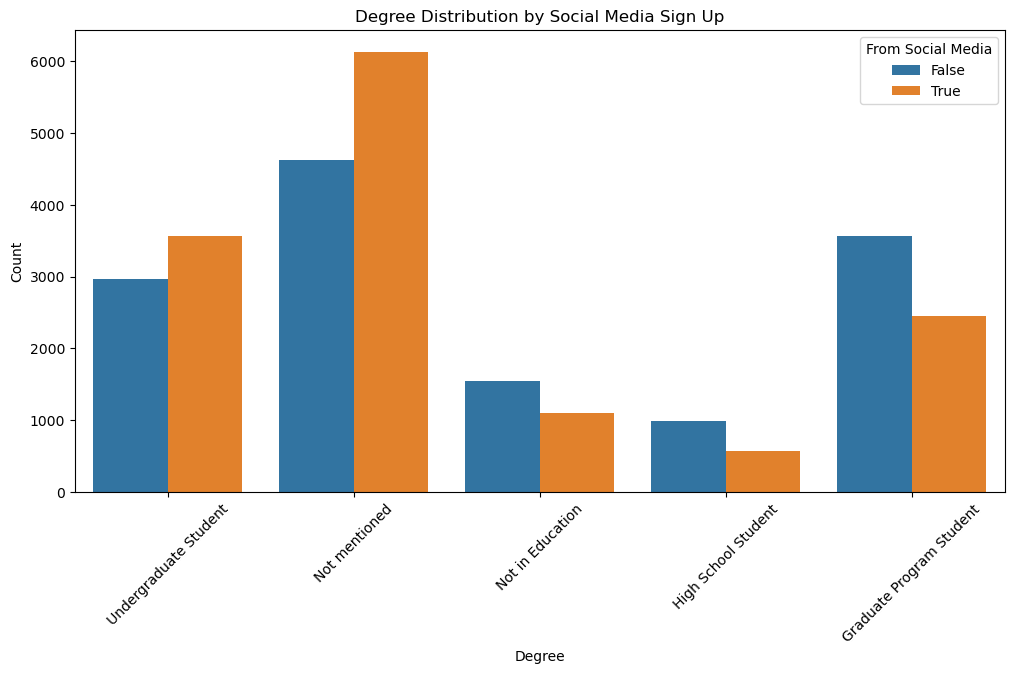

In [35]:
# Convert isFromSocialMedia to string if necessary
df['isFromSocialMedia'] = df['isFromSocialMedia'].astype(str)

# Degree vs isFromSocialMedia count plot
plt.figure(figsize=(12, 6))
sns.countplot(x='Degree', hue='isFromSocialMedia', data=df)
plt.title('Degree Distribution by Social Media Sign Up')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='From Social Media')  # This should add the legend correctly
plt.show()


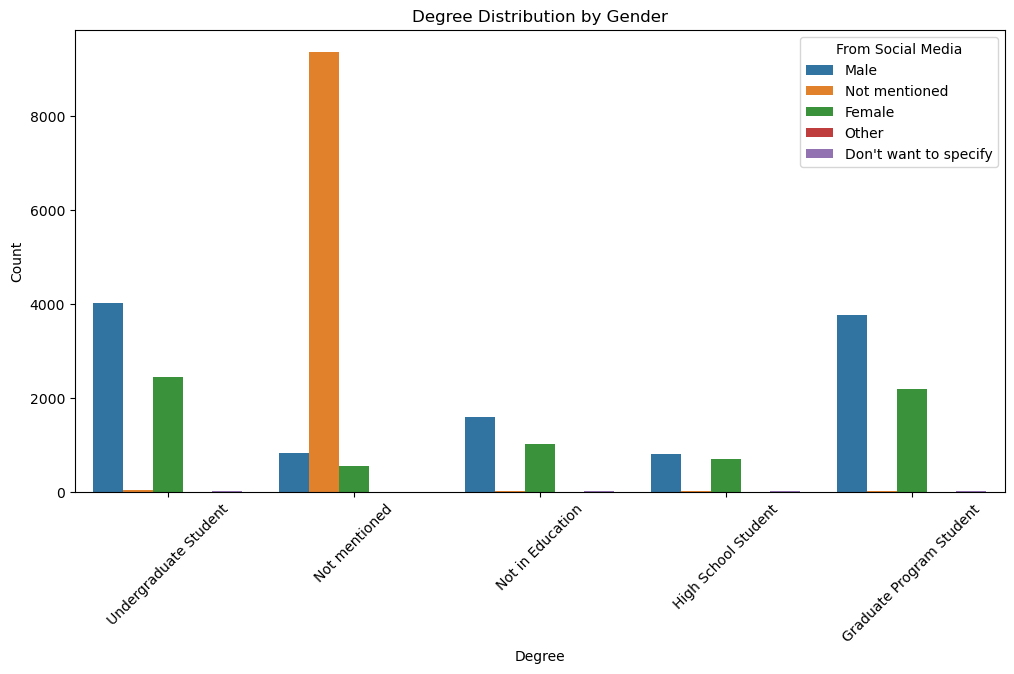

In [36]:
# Degree vs Gender
plt.figure(figsize=(12, 6))
sns.countplot(x='Degree', hue='Gender', data=df)
plt.title('Degree Distribution by Gender')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='From Social Media')
plt.show()

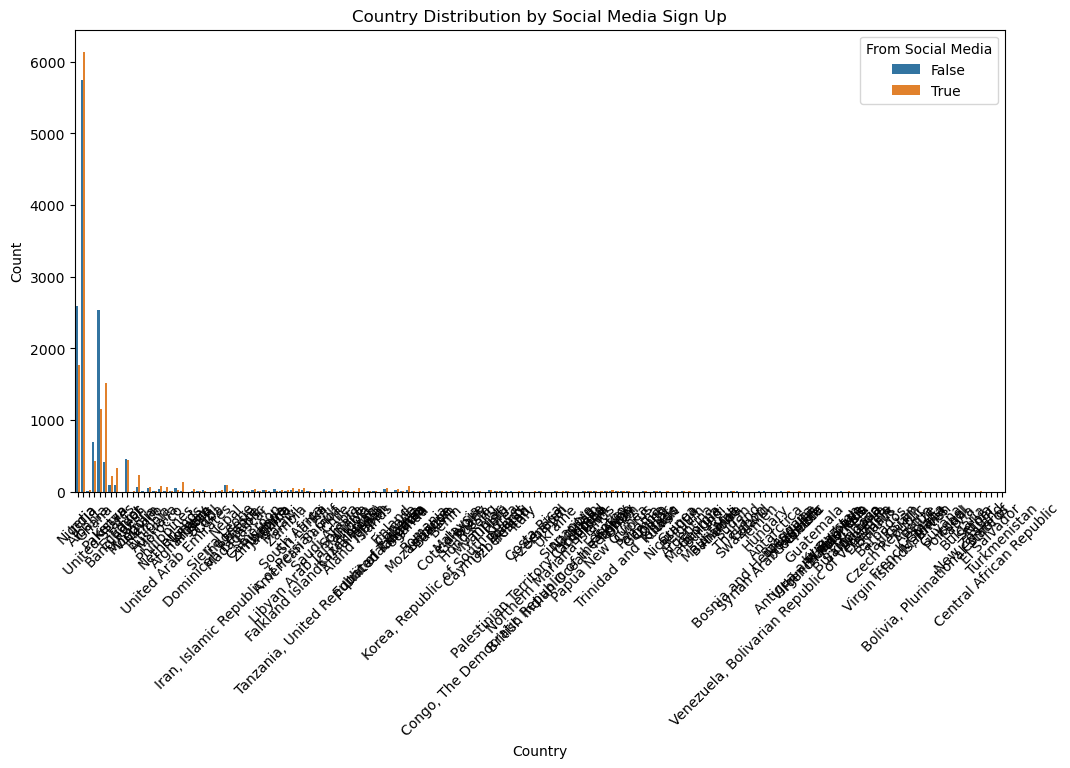

In [37]:
# Country vs isFromSocialMedia
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='isFromSocialMedia', data=df)
plt.title('Country Distribution by Social Media Sign Up')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='From Social Media')
plt.show()


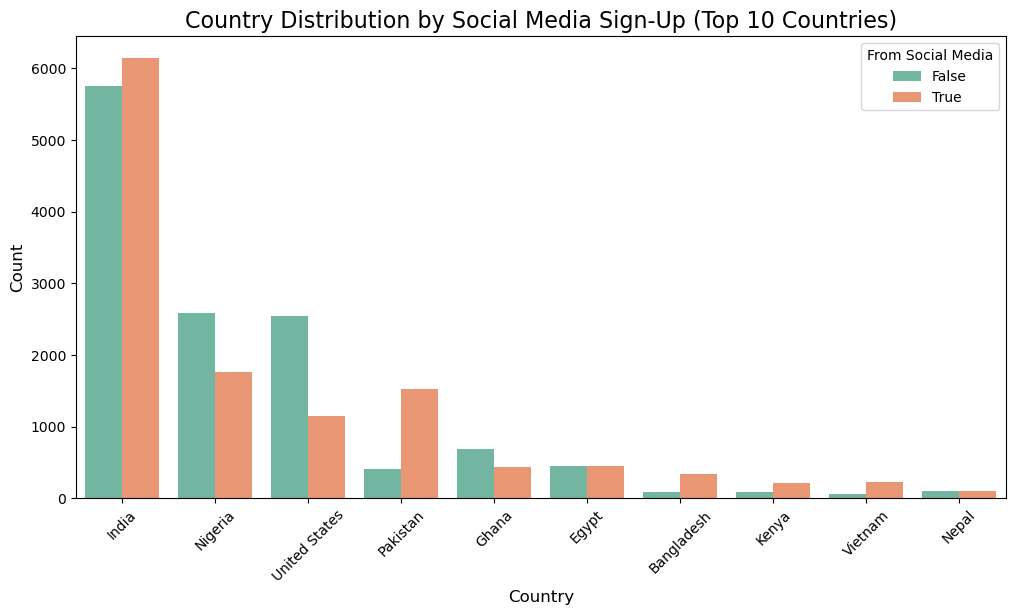

In [38]:
# Country vs isFromSocialMedia
# Find the top 10 countries by total count
top_10_countries = df['Country'].value_counts().head(10)

# Filter the dataframe for only the top 10 countries
df_top_10 = df[df['Country'].isin(top_10_countries.index)]

# Plot Country Distribution by Social Media Sign-Up (for top 10 countries)
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='isFromSocialMedia', data=df_top_10, palette='Set2', 
              order=top_10_countries.index)  # Ensure top 10 countries are ordered by count
plt.title('Country Distribution by Social Media Sign-Up (Top 10 Countries)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='From Social Media')
plt.show()

In [147]:
# Countplot for year and categorical variable
plt.figure(figsize=(12, 6))
sns.countplot(x='Sign Up Date', hue='Country', data=df_cleaned)
plt.title('Country Distribution over Years')
plt.xticks(rotation=45)
plt.show()



KeyboardInterrupt



In [146]:
df.columns


Index(['PreferredSponsors', 'Gender', 'Country', 'Degree', 'Sign Up Date',
       'city', 'zip', 'isFromSocialMedia'],
      dtype='object')

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2115347314.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Sign Up Date'] = pd.to_datetime(df_cleaned['Sign Up Date'], errors='coerce')
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\2115347314.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Year'] = df_cleaned['Sign Up Date'].dt.year


<Figure size 1000x600 with 0 Axes>

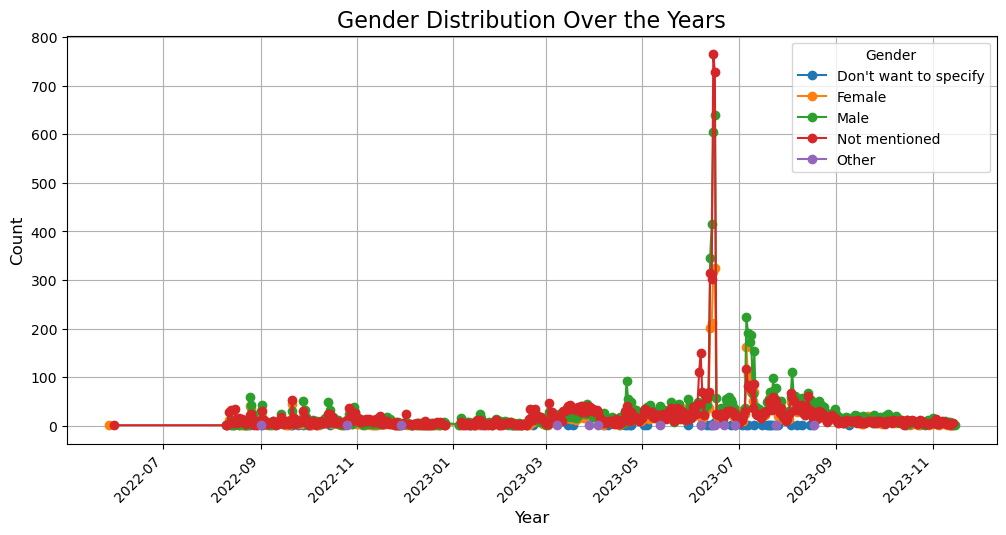

In [39]:
# Ensure the date column is in datetime format
df_cleaned['Sign Up Date'] = pd.to_datetime(df_cleaned['Sign Up Date'], errors='coerce')

# Extract the year from the date column
df_cleaned['Year'] = df_cleaned['Sign Up Date'].dt.year

# Group by year and gender and count occurrences
gender_over_years = df_cleaned.groupby(['Sign Up Date', 'Gender']).size().unstack()

# Plot the line plot
plt.figure(figsize=(10, 6))
gender_over_years.plot(kind='line', marker='o', figsize=(12, 6))

# Add labels and title
plt.title('Gender Distribution Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)

# Display the plot
plt.show()


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\3018045872.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['Sign Up Date'] = pd.to_datetime(df_top_10['Sign Up Date'], errors='coerce')
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\3018045872.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['Year'] = df_top_10['Sign Up Date'].dt.year


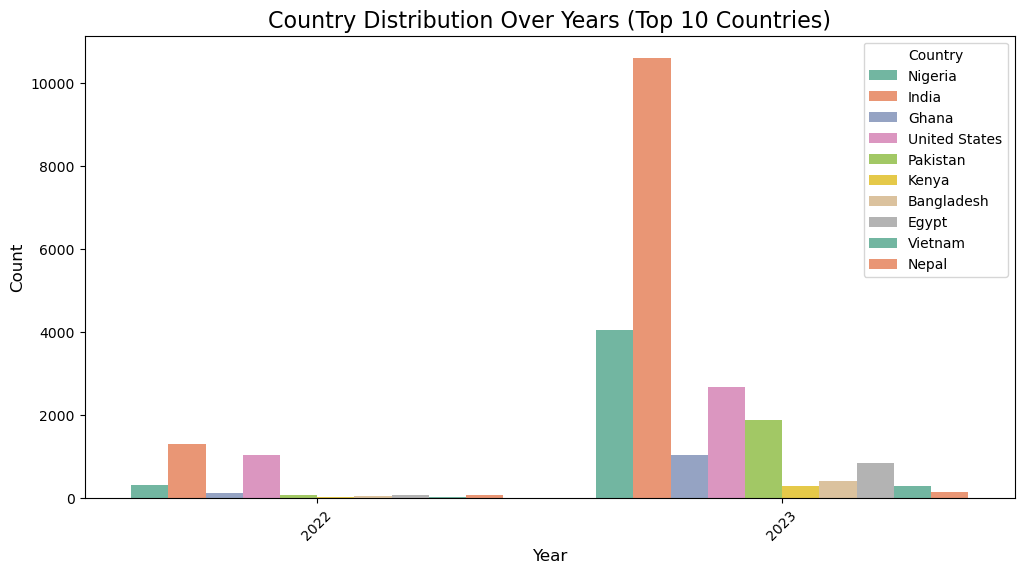

In [40]:

# Identify the top 10 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(10).index

# Filter the dataframe to only include rows from the top 10 countries
df_top_10 = df_cleaned[df_cleaned['Country'].isin(top_10_countries)]

# Convert 'Sign Up Date' to datetime if not already done
df_top_10['Sign Up Date'] = pd.to_datetime(df_top_10['Sign Up Date'], errors='coerce')

# Extract the year from the 'Sign Up Date' column
df_top_10['Year'] = df_top_10['Sign Up Date'].dt.year

# Create a countplot for the top 10 countries by year
plt.figure(figsize=(12, 6))
sns.countplot(x='Year', hue='Country', data=df_top_10, palette='Set2')
plt.title('Country Distribution Over Years (Top 10 Countries)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.show()


C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\781269395.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['Sign Up Date'] = pd.to_datetime(df_top_10['Sign Up Date'], errors='coerce')
C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\781269395.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['Year'] = df_top_10['Sign Up Date'].dt.year


AttributeError: 'numpy.int32' object has no attribute 'startswith'

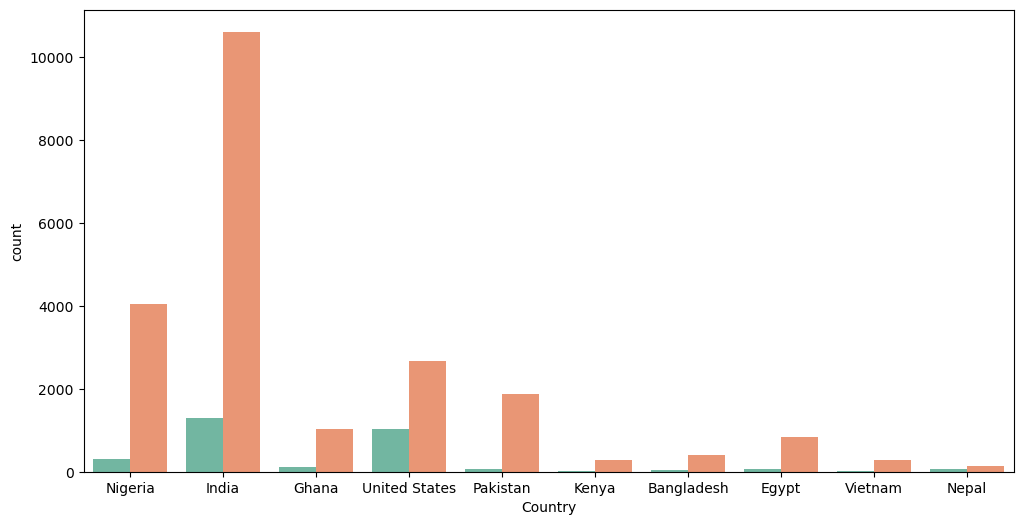

In [41]:

# Identify the top 10 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(10).index

# Filter the dataframe to only include rows from the top 10 countries
df_top_10 = df_cleaned[df_cleaned['Country'].isin(top_10_countries)]

# Convert 'Sign Up Date' to datetime if not already done
df_top_10['Sign Up Date'] = pd.to_datetime(df_top_10['Sign Up Date'], errors='coerce')

# Extract the year from the 'Sign Up Date' column
df_top_10['Year'] = df_top_10['Sign Up Date'].dt.year

# Create a countplot for the top 10 countries by year
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Year', data=df_top_10, palette='Set2')
plt.title('Country Distribution Over Years (Top 10 Countries)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.show()


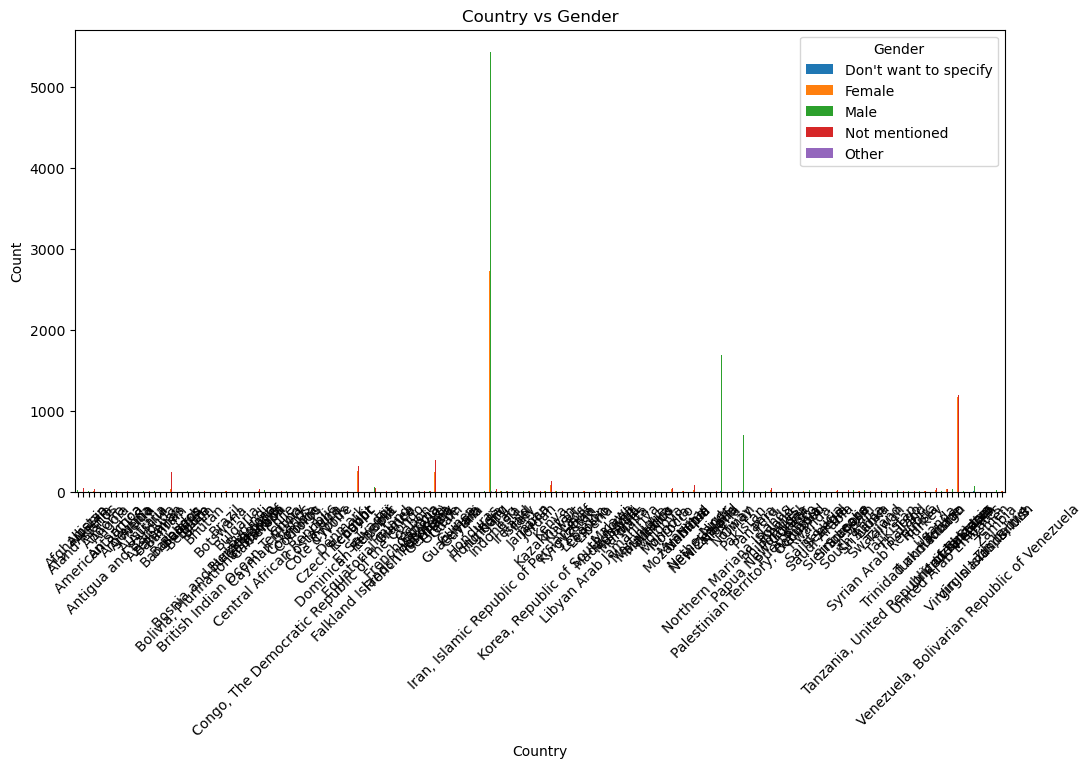

In [42]:
# Crosstab for categorical variables
crosstab_result = pd.crosstab(df_cleaned['Country'], df_cleaned['Gender'])

# Plot grouped bar plot
crosstab_result.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.title('Country vs Gender')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


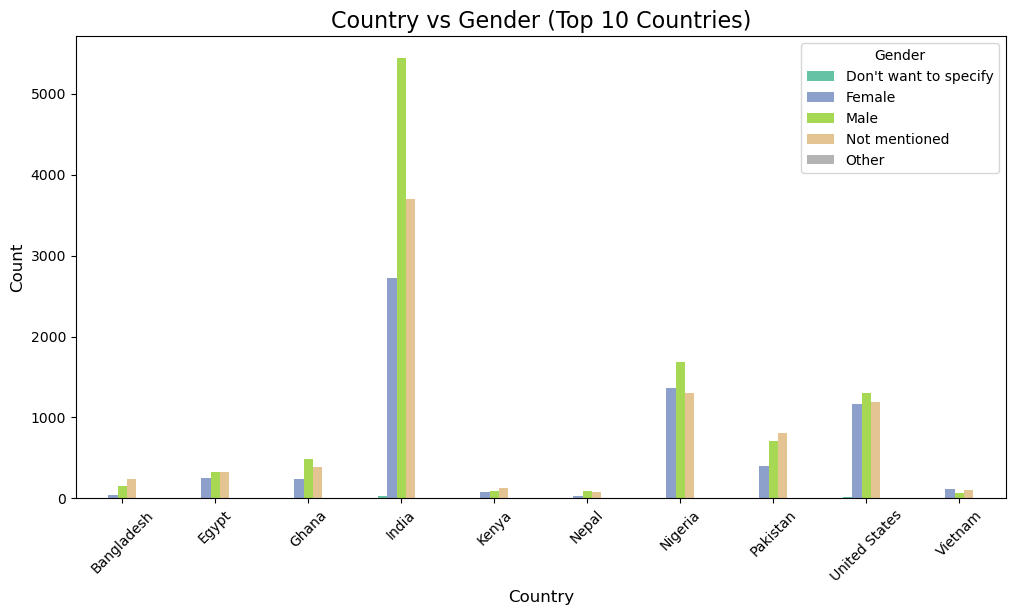

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Find the top 10 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(10).index

# Create a crosstab for only the top 10 countries
crosstab_result = pd.crosstab(df_cleaned[df_cleaned['Country'].isin(top_10_countries)]['Country'],
                              df_cleaned['Gender'])

# Plot grouped bar plot
crosstab_result.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='Set2')
plt.title('Country vs Gender (Top 10 Countries)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()


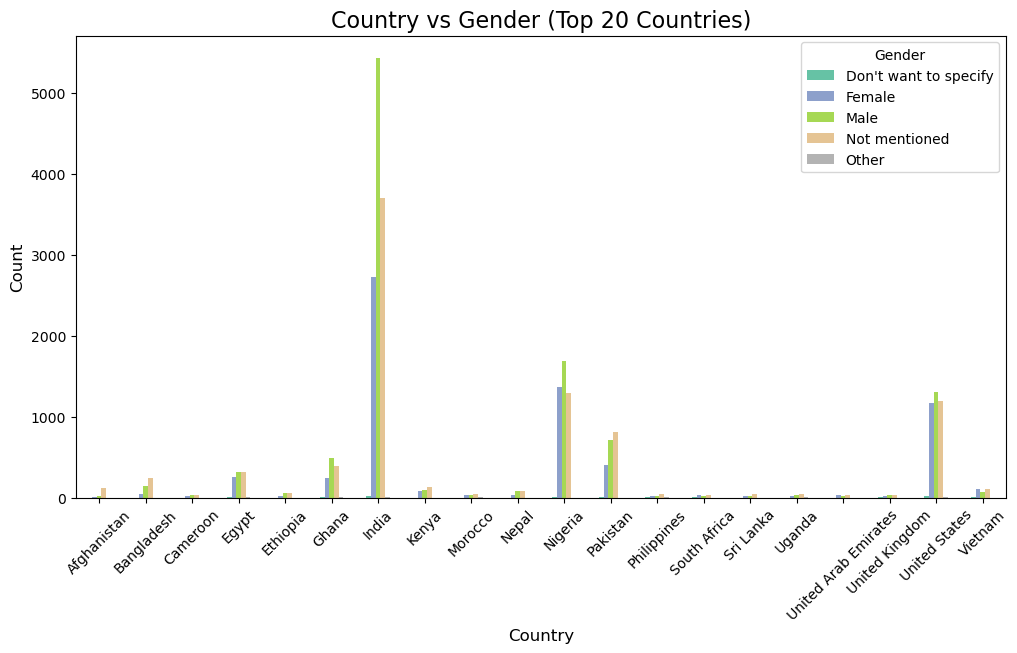

In [44]:
# Find the top 20 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(20).index

# Create a crosstab for only the top 10 countries
crosstab_result = pd.crosstab(df_cleaned[df_cleaned['Country'].isin(top_10_countries)]['Country'],
                              df_cleaned['Gender'])

# Plot grouped bar plot
crosstab_result.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='Set2')
plt.title('Country vs Gender (Top 20 Countries)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

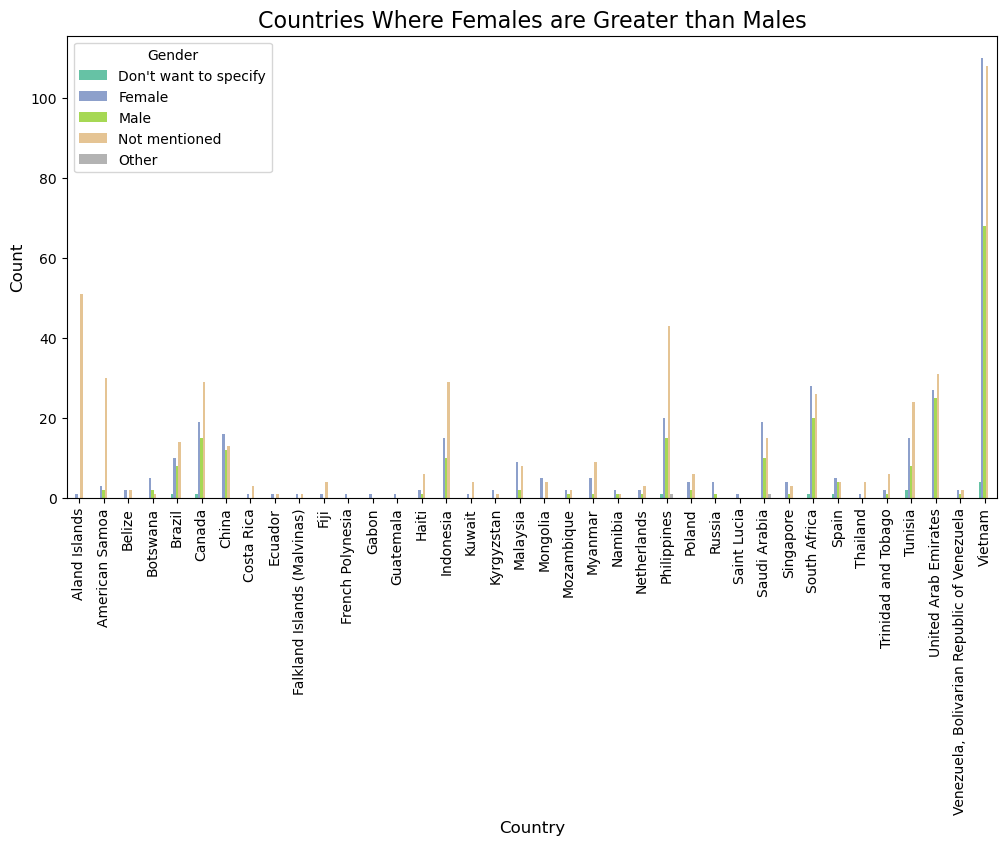

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab for Country vs Gender
crosstab_result = pd.crosstab(df_cleaned['Country'], df_cleaned['Gender'])

# Filter the crosstab to only include rows where females are greater than males
filtered_crosstab = crosstab_result[crosstab_result['Female'] > crosstab_result['Male']]

# Plot grouped bar plot for filtered data
filtered_crosstab.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='Set2')
plt.title('Countries Where Females are Greater than Males', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.show()


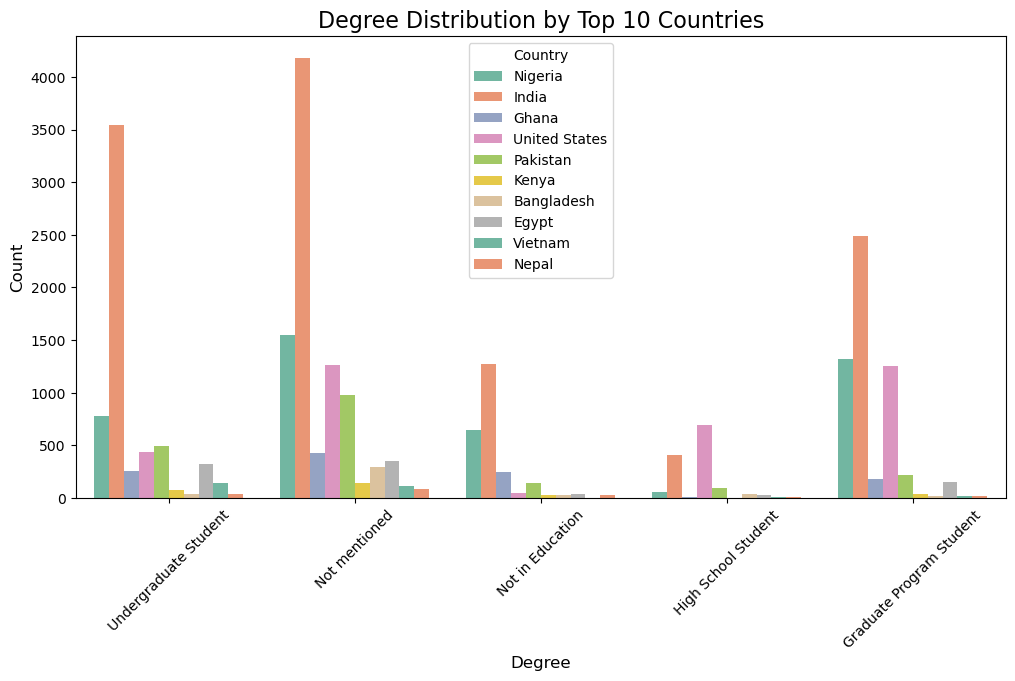

In [46]:
# Find the top 10 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(10).index

# Filter the dataframe to only include rows from the top 10 countries
df_top_10 = df_cleaned[df_cleaned['Country'].isin(top_10_countries)]

# Create a countplot for Degree distribution by top 10 countries
plt.figure(figsize=(12, 6))
sns.countplot(x='Degree', hue='Country', data=df_top_10, palette='Set2')
plt.title('Degree Distribution by Top 10 Countries', fontsize=16)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.show()

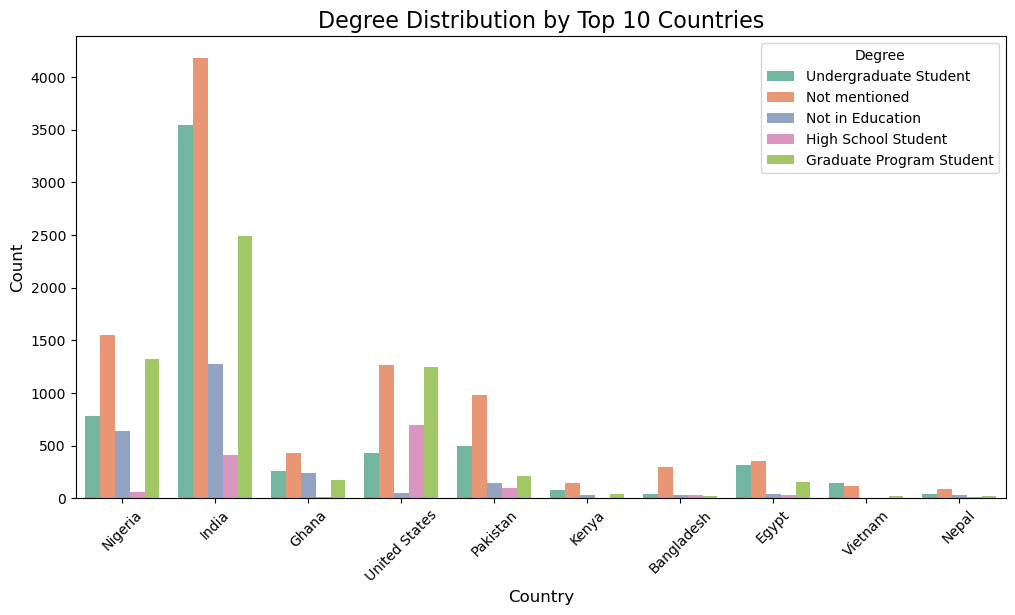

In [47]:
# Find the top 10 countries by frequency
top_10_countries = df_cleaned['Country'].value_counts().head(10).index

# Filter the dataframe to only include rows from the top 10 countries
df_top_10 = df_cleaned[df_cleaned['Country'].isin(top_10_countries)]

# Create a countplot for Degree distribution by top 10 countries
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Degree', data=df_top_10, palette='Set2')
plt.title('Degree Distribution by Top 10 Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Degree')
plt.show()


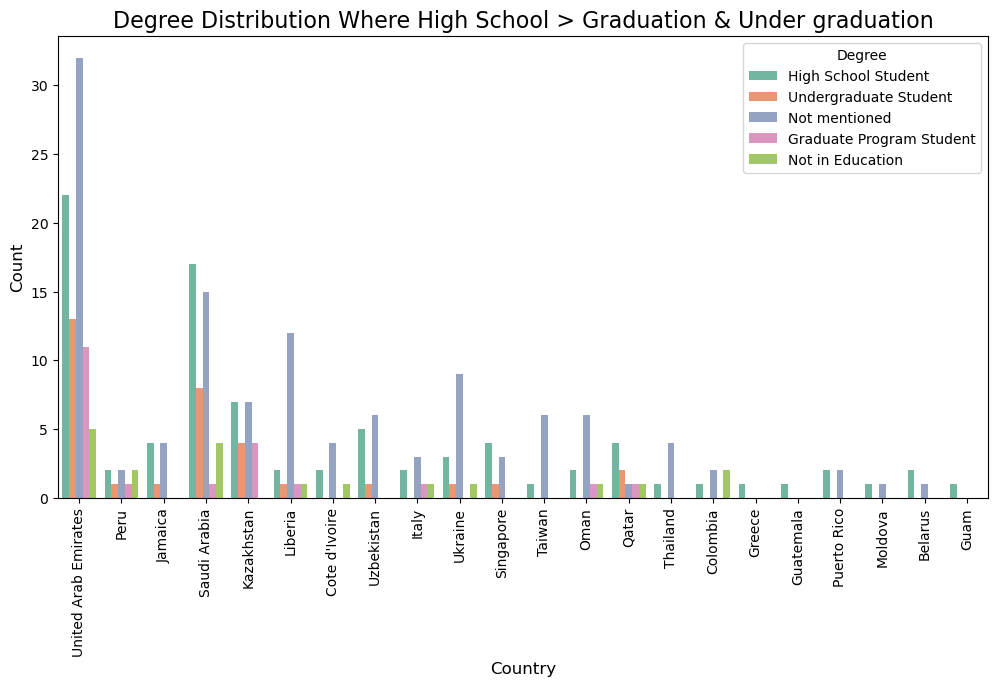

In [48]:

# Create a crosstab for Degree distribution by Country
crosstab_result = pd.crosstab(df_cleaned['Country'], df_cleaned['Degree'])

# Filter for countries where High School count is greater than Graduation/Undergraduation count
filtered_crosstab = crosstab_result[(crosstab_result['High School Student'] > crosstab_result['Graduate Program Student']) &
(crosstab_result['High School Student'] > crosstab_result['Undergraduate Student'])]

# Extract the countries that meet the condition
filtered_countries = filtered_crosstab.index

# Filter the original dataframe to include only these countries
df_filtered = df_cleaned[df_cleaned['Country'].isin(filtered_countries)]

# Create a countplot for Degree distribution by filtered countries
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Degree', data=df_filtered, palette='Set2')
plt.title('Degree Distribution Where High School > Graduation & Under graduation', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Degree')
plt.show()


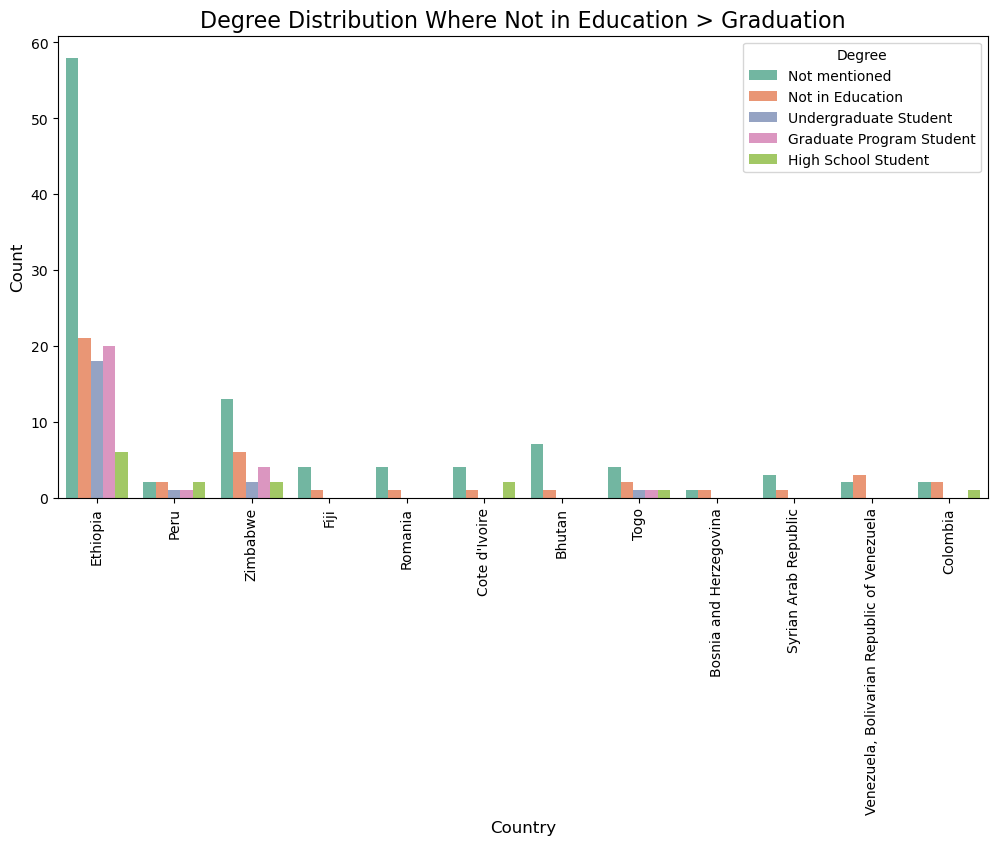

In [49]:

# Create a crosstab for Degree distribution by Country
crosstab_result = pd.crosstab(df_cleaned['Country'], df_cleaned['Degree'])

# Filter for countries where Not in Education count is greater than Graduation/Undergraduation count
filtered_crosstab = crosstab_result[(crosstab_result['Not in Education'] > crosstab_result['Graduate Program Student']) & (crosstab_result['Not in Education'] > crosstab_result['Undergraduate Student'])]

# Extract the countries that meet the condition
filtered_countries = filtered_crosstab.index

# Filter the original dataframe to include only these countries
df_filtered = df_cleaned[df_cleaned['Country'].isin(filtered_countries)]

# Create a countplot for Degree distribution by filtered countries
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Degree', data=df_filtered, palette='Set2')
plt.title('Degree Distribution Where Not in Education > Graduation', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Degree')
plt.show()


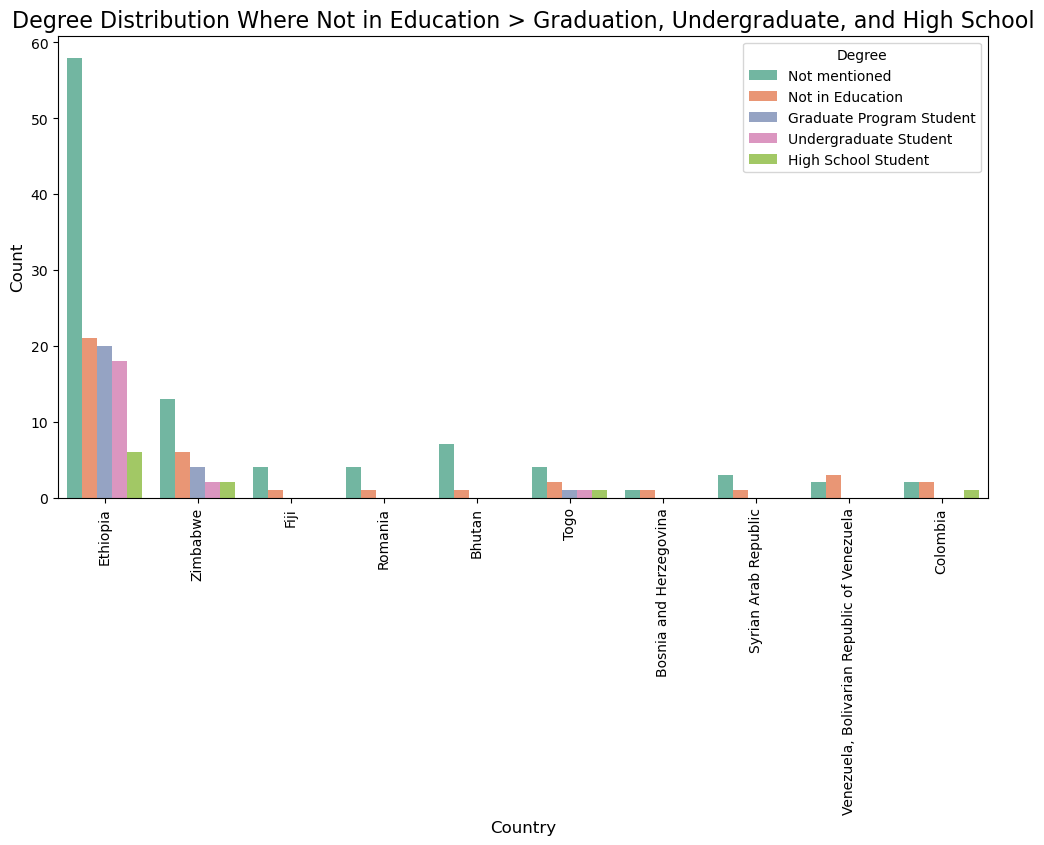

In [50]:
# Create a crosstab for Degree distribution by Country
crosstab_result = pd.crosstab(df_cleaned['Country'], df_cleaned['Degree'])

# Filter for countries where Not in Education count is greater than Graduation, Undergraduate, and High School counts
filtered_crosstab = crosstab_result[
    (crosstab_result['Not in Education'] > crosstab_result['Graduate Program Student']) & 
    (crosstab_result['Not in Education'] > crosstab_result['Undergraduate Student']) & 
    (crosstab_result['Not in Education'] > crosstab_result['High School Student'])
]

# Extract the countries that meet the condition
filtered_countries = filtered_crosstab.index

# Filter the original dataframe to include only these countries
df_filtered = df_cleaned[df_cleaned['Country'].isin(filtered_countries)]

# Create a countplot for Degree distribution by filtered countries
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', hue='Degree', data=df_filtered, palette='Set2')
plt.title('Degree Distribution Where Not in Education > Graduation, Undergraduate, and High School', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Degree')
plt.show()

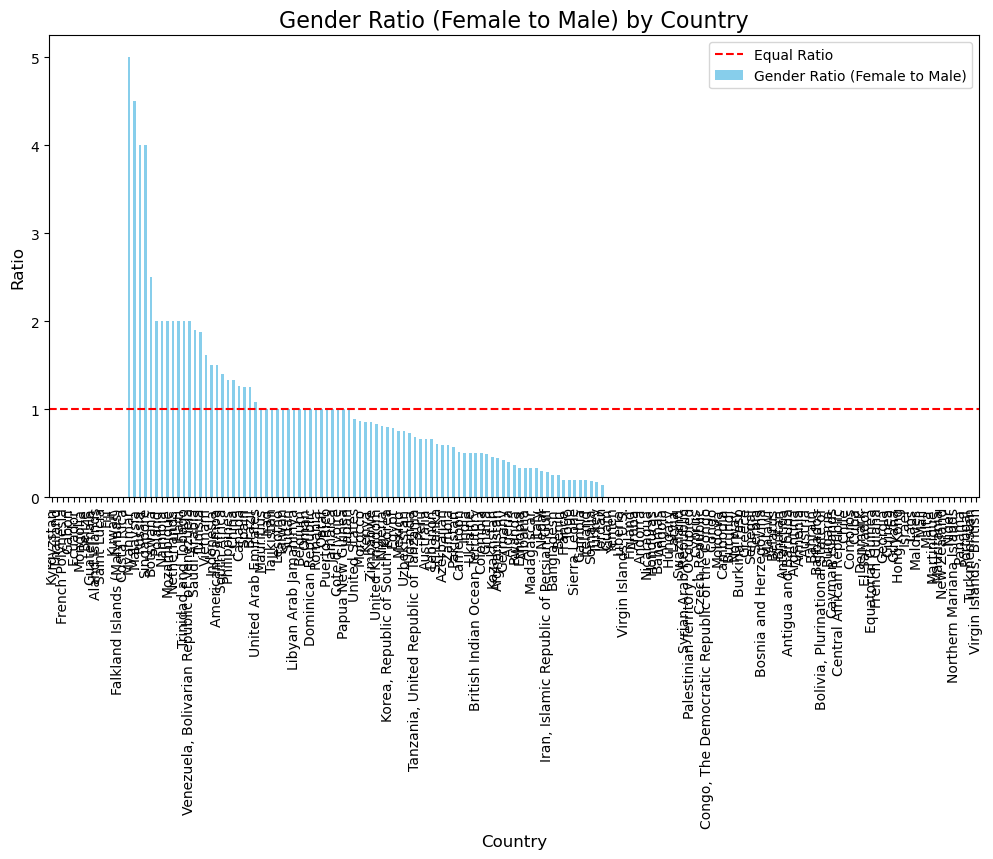

In [51]:
# Calculate gender counts by country
gender_ratio = df_cleaned.groupby('Country')['Gender'].value_counts().unstack().fillna(0)

# Calculate the gender ratio
gender_ratio['Gender Ratio (Female to Male)'] = gender_ratio['Female'] / gender_ratio['Male']

# Plotting Gender Ratio by Country
plt.figure(figsize=(12, 6))
gender_ratio['Gender Ratio (Female to Male)'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Gender Ratio (Female to Male) by Country', fontsize=16)
plt.ylabel('Ratio', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=90)
plt.axhline(1, color='red', linestyle='--', label='Equal Ratio')
plt.legend()
plt.show()


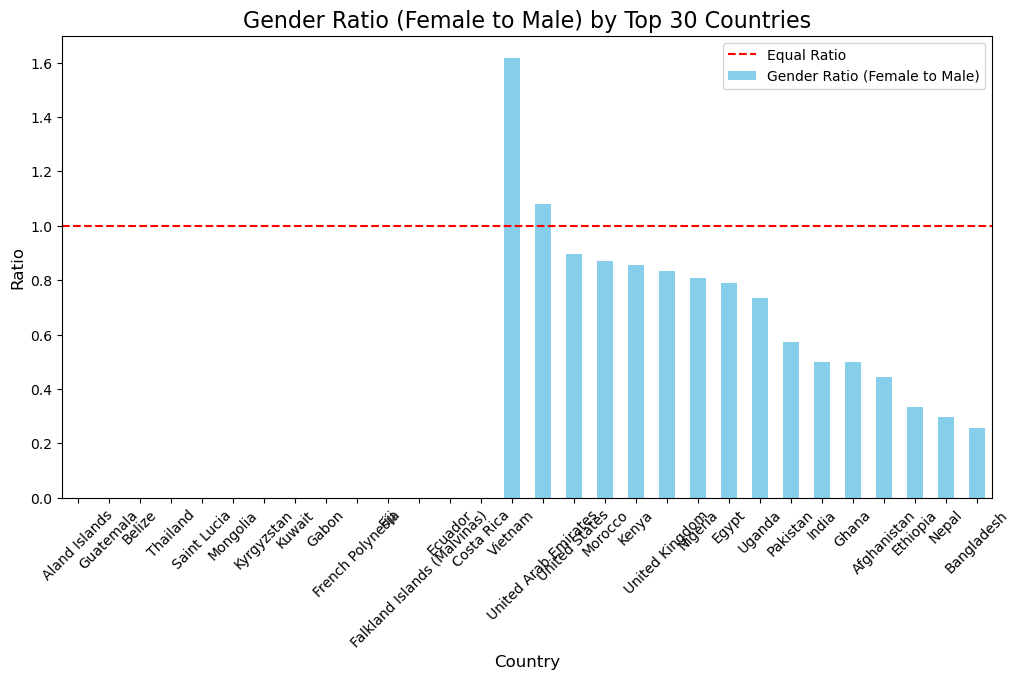

In [54]:
# Calculate gender counts by country
gender_ratio = df_cleaned.groupby('Country')['Gender'].value_counts().unstack().fillna(0)

# Calculate the gender ratio
gender_ratio['Gender Ratio (Female to Male)'] = gender_ratio['Female'] / gender_ratio['Male']

# Filter for top 30 countries
top_30_countries = gender_ratio.sum(axis=1).nlargest(30).index
gender_ratio_top_30 = gender_ratio.loc[top_30_countries]

# Plotting Gender Ratio by Top 30 Countries
plt.figure(figsize=(12, 6))
gender_ratio_top_30['Gender Ratio (Female to Male)'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Gender Ratio (Female to Male) by Top 30 Countries', fontsize=16)
plt.ylabel('Ratio', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(1, color='red', linestyle='--', label='Equal Ratio')
plt.legend()
plt.show()


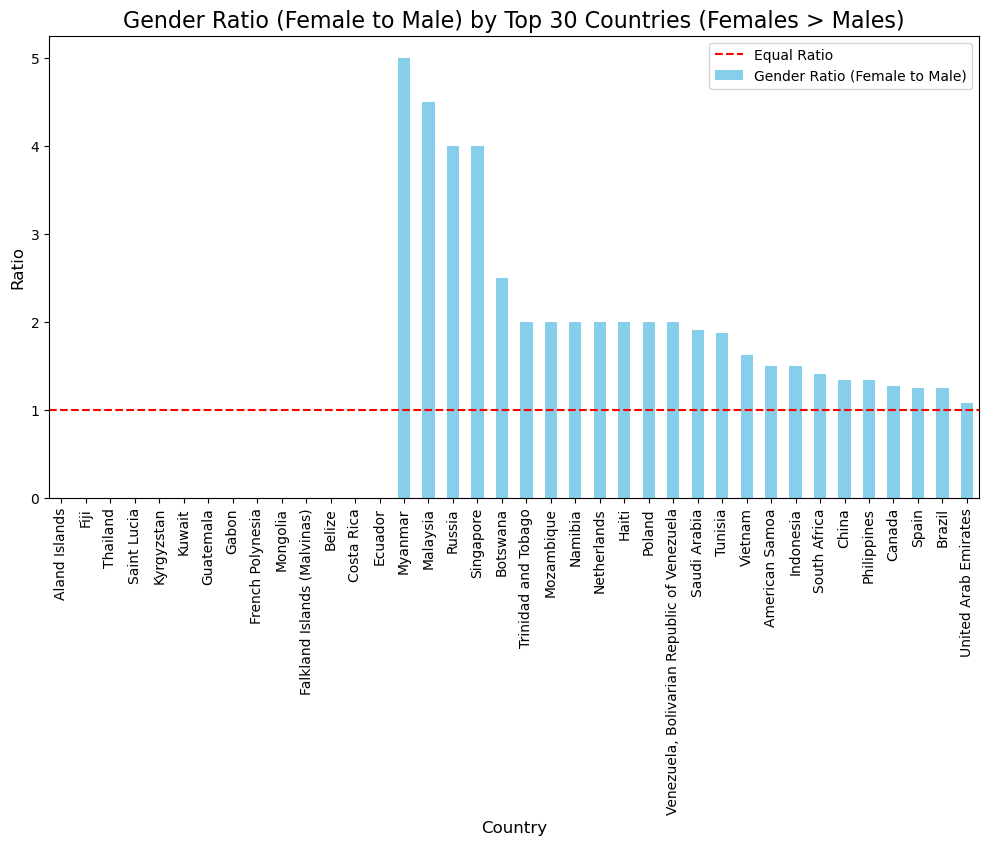

In [56]:
# Calculate gender counts by country
gender_ratio = df_cleaned.groupby('Country')['Gender'].value_counts().unstack().fillna(0)

# Calculate the gender ratio
gender_ratio['Gender Ratio (Female to Male)'] = gender_ratio['Female'] / gender_ratio['Male']

# Filter for top 30 countries
top_30_countries = gender_ratio.sum(axis=1).index
gender_ratio_top_30 = gender_ratio.loc[top_30_countries]

# Filter for countries where the female ratio is greater than 1
gender_ratio_top_30_females_more = gender_ratio_top_30[gender_ratio_top_30['Gender Ratio (Female to Male)'] > 1]

# Plotting Gender Ratio by Top 30 Countries (Females > Males)
plt.figure(figsize=(12, 6))
gender_ratio_top_30_females_more['Gender Ratio (Female to Male)'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Gender Ratio (Female to Male) by Top 30 Countries (Females > Males)', fontsize=16)
plt.ylabel('Ratio', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=90)
plt.axhline(1, color='red', linestyle='--', label='Equal Ratio')
plt.legend()
plt.show()


<Figure size 1200x600 with 0 Axes>

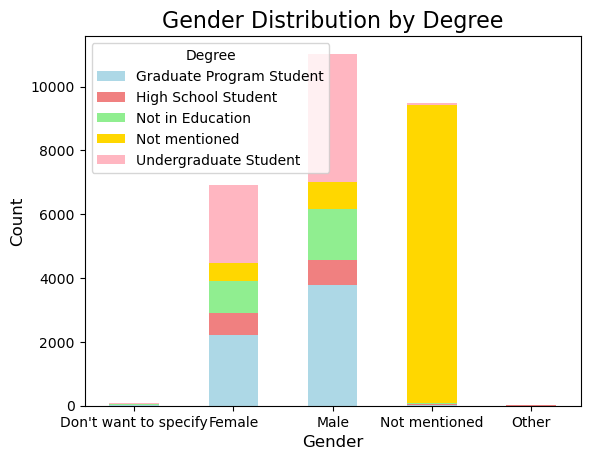

In [55]:
# Create a crosstab for Gender and Degree
gender_degree_crosstab = pd.crosstab(df_cleaned['Gender'], df_cleaned['Degree'])

# Plotting the crosstab
plt.figure(figsize=(12, 6))
gender_degree_crosstab.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink'])
plt.title('Gender Distribution by Degree', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Degree')
plt.show()


<Figure size 1200x600 with 0 Axes>

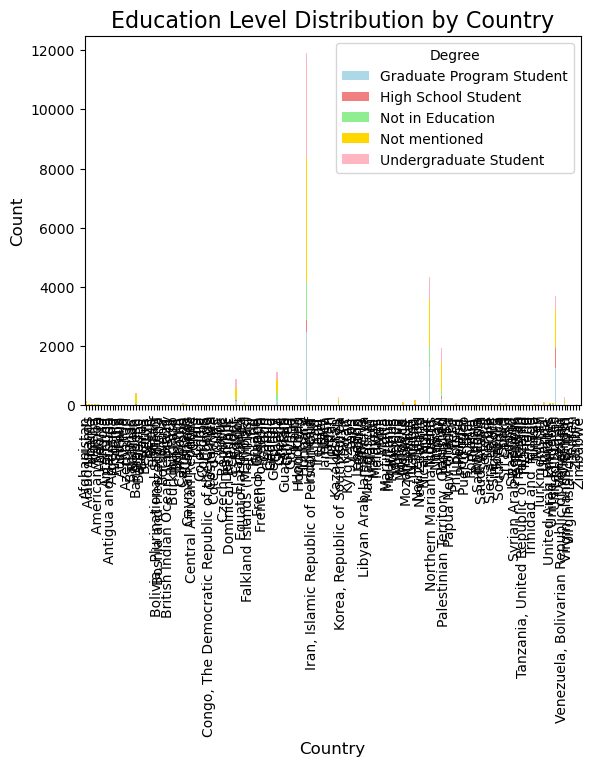

In [58]:
# Create a crosstab for Education Level by Country
education_crosstab = pd.crosstab(df_cleaned['Country'], df_cleaned['Degree'])

# Plotting Education Level by Country
plt.figure(figsize=(12, 6))
education_crosstab.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink'])
plt.title('Education Level Distribution by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Degree')
plt.show()


<Figure size 1200x600 with 0 Axes>

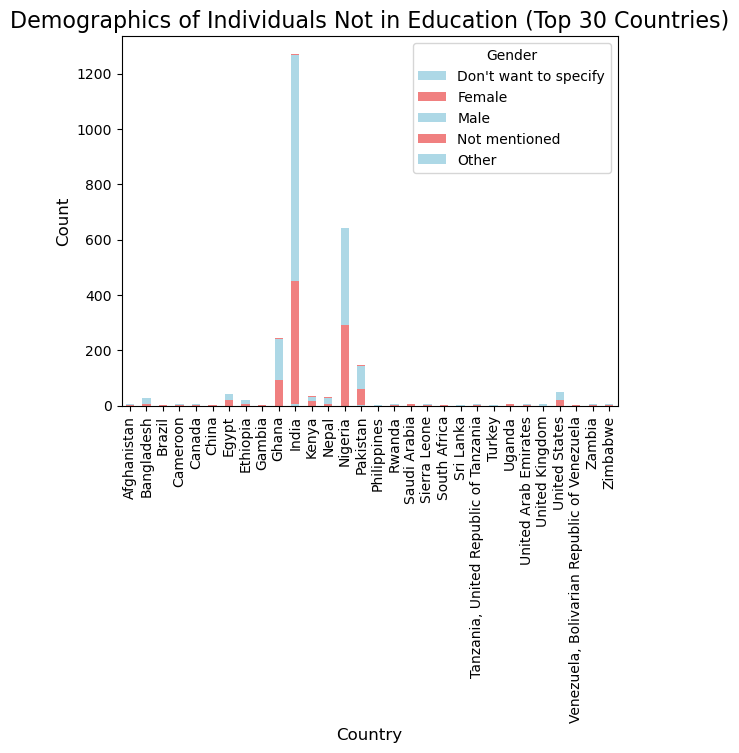

In [60]:

# Step 1: Filter for individuals 'Not in Education'
not_in_education_df = df_cleaned[df_cleaned['Degree'] == 'Not in Education']

# Step 2: Count occurrences by country
not_in_education_counts = not_in_education_df['Country'].value_counts()

# Step 3: Get the top 30 countries
top_30_countries = not_in_education_counts.nlargest(30).index

# Step 4: Filter the DataFrame for top 30 countries
not_in_education_top_30 = not_in_education_df[not_in_education_df['Country'].isin(top_30_countries)]

# Step 5: Create a crosstab for demographics (Gender and Country)
not_in_education_crosstab_top_30 = pd.crosstab(not_in_education_top_30['Country'], not_in_education_top_30['Gender'])

# Step 6: Plotting demographics
plt.figure(figsize=(12, 6))
not_in_education_crosstab_top_30.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral'])
plt.title('Demographics of Individuals Not in Education (Top 30 Countries)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Gender')
plt.show()


<Figure size 200x600 with 0 Axes>

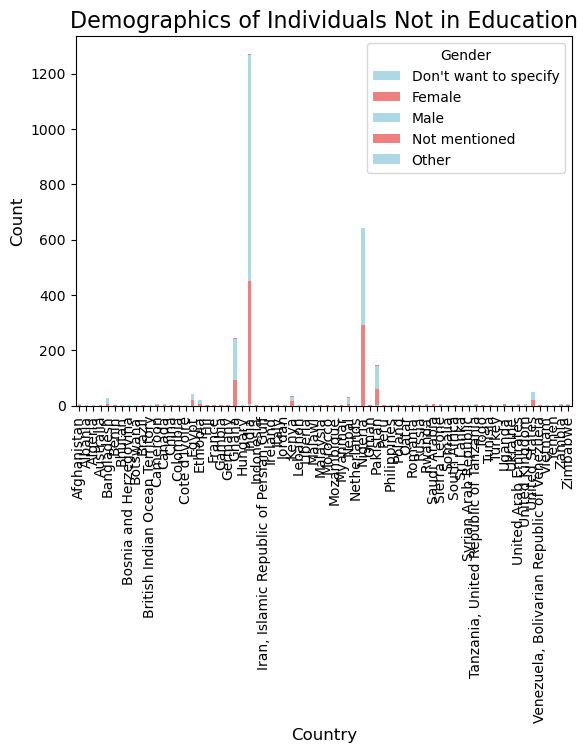

In [61]:
# Filter the dataframe for individuals 'Not in Education'
not_in_education = df_cleaned[df_cleaned['Degree'] == 'Not in Education']

# Analyze demographics (Gender and Country) for individuals Not in Education
not_in_education_crosstab = pd.crosstab(not_in_education['Country'], not_in_education['Gender'])

# Plotting demographics
plt.figure(figsize=(2, 6))
not_in_education_crosstab.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral'])
plt.title('Demographics of Individuals Not in Education', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Gender')
plt.show()


<Figure size 1200x600 with 0 Axes>

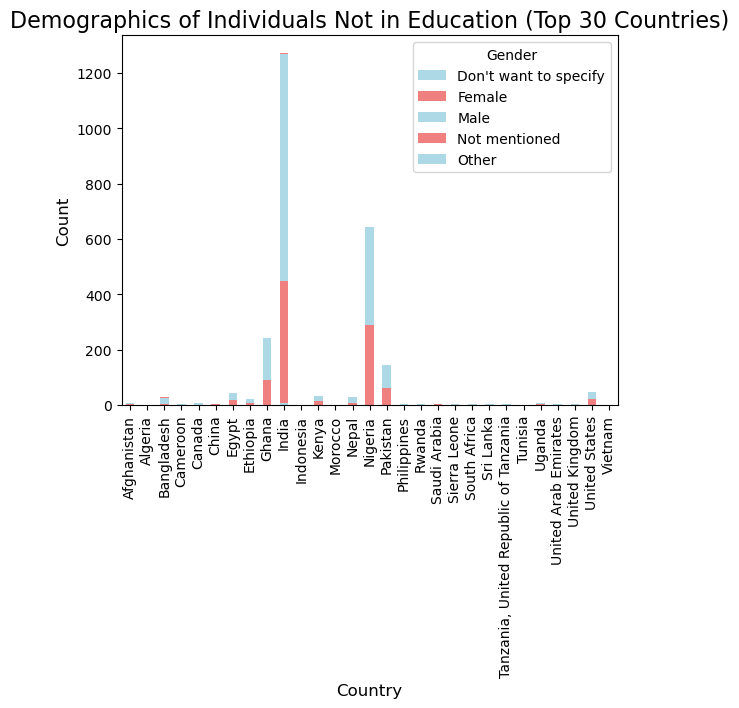

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_cleaned is your original DataFrame

# Step 1: Count occurrences by country to find top 30 countries
country_counts = df_cleaned['Country'].value_counts()
top_30_countries = country_counts.nlargest(30).index

# Step 2: Filter the original DataFrame for top 30 countries
filtered_df_top_30 = df_cleaned[df_cleaned['Country'].isin(top_30_countries)]

# Step 3: Filter for individuals 'Not in Education'
not_in_education_top_30 = filtered_df_top_30[filtered_df_top_30['Degree'] == 'Not in Education']

# Step 4: Create a crosstab for demographics (Gender and Country)
not_in_education_crosstab_top_30 = pd.crosstab(not_in_education_top_30['Country'], not_in_education_top_30['Gender'])

# Step 5: Plotting demographics
plt.figure(figsize=(12, 6))
not_in_education_crosstab_top_30.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral'])
plt.title('Demographics of Individuals Not in Education (Top 30 Countries)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Gender')
plt.show()


<Figure size 1000x600 with 0 Axes>

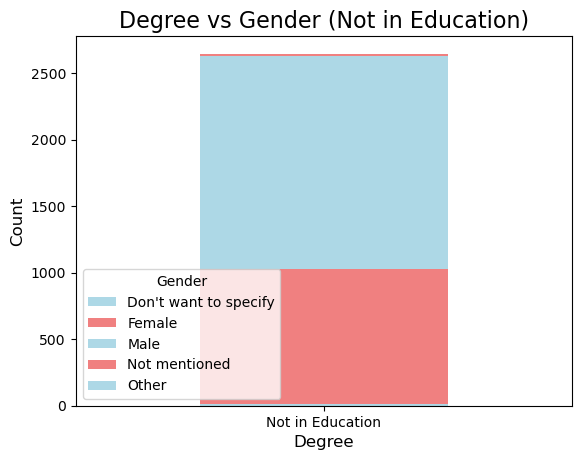

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_cleaned is your original DataFrame

# Step 1: Count occurrences by country to find countries
country_counts = df_cleaned['Country'].value_counts()
countries = country_counts.index

# Step 2: Filter the original DataFrame for countries
filtered_df_top = df_cleaned[df_cleaned['Country'].isin(countries)]

# Step 3: Filter for individuals 'Not in Education'
not_in_education_top = filtered_df_top[filtered_df_top['Degree'] == 'Not in Education']

# Step 4: Create a crosstab for Degree vs Gender
degree_gender_crosstab = pd.crosstab(not_in_education_top['Degree'], not_in_education_top['Gender'])

# Step 5: Plotting Degree vs Gender
plt.figure(figsize=(10, 6))
degree_gender_crosstab.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral'])
plt.title('Degree vs Gender (Not in Education)', fontsize=16)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()


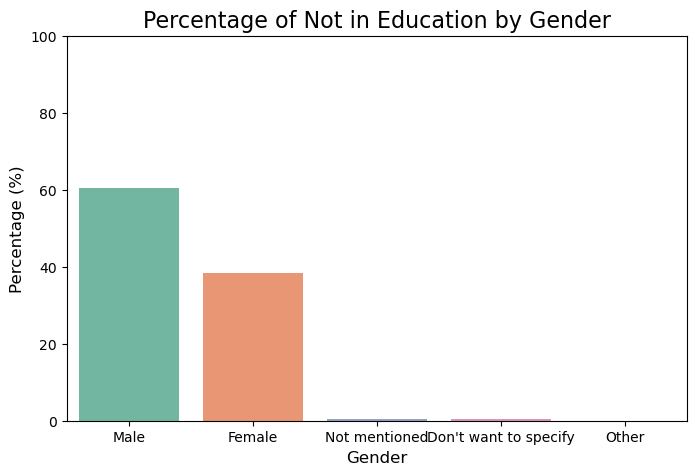

                  Gender  Percentage
0                   Male   60.544218
1                 Female   38.397581
2          Not mentioned    0.529101
3  Don't want to specify    0.491308
4                  Other    0.037793


In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_cleaned is your original DataFrame

# Step 1: Filter for individuals 'Not in Education'
not_in_education = df_cleaned[df_cleaned['Degree'] == 'Not in Education']

# Step 2: Count total individuals in 'Not in Education'
total_not_in_education = len(not_in_education)

# Step 3: Count males and females
gender_counts = not_in_education['Gender'].value_counts()

# Step 4: Calculate percentages
percentages = (gender_counts / total_not_in_education) * 100

# Step 5: Create a DataFrame for plotting
percentage_df = percentages.reset_index()
percentage_df.columns = ['Gender', 'Percentage']

# Step 6: Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Percentage', data=percentage_df, palette='Set2')
plt.title('Percentage of Not in Education by Gender', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Gender', fontsize=12)
plt.ylim(0, 100)
plt.show()

# Output the percentage values for clarity
print(percentage_df)


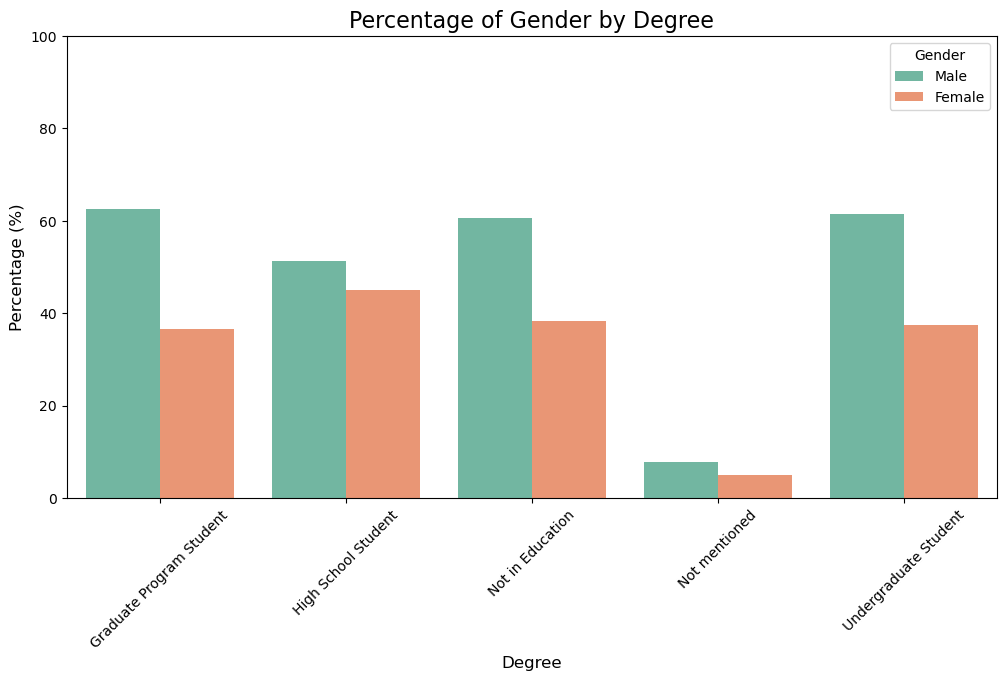

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_cleaned is your original DataFrame

# Step 1: Group by Degree and Gender and count occurrences
degree_gender_counts = df_cleaned.groupby(['Degree', 'Gender']).size().unstack(fill_value=0)

# Step 2: Calculate total counts for each Degree
degree_counts = degree_gender_counts.sum(axis=1)

# Step 3: Calculate percentages
percentage_df = (degree_gender_counts.div(degree_counts, axis=0) * 100).reset_index()

# Step 4: Melt the DataFrame for plotting
percentage_melted = percentage_df.melt(id_vars='Degree', value_vars=['Male', 'Female'], var_name='Gender', value_name='Percentage')

# Step 5: Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Degree', y='Percentage', hue='Gender', data=percentage_melted, palette='Set2')
plt.title('Percentage of Gender by Degree', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Degree', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()


In [11]:
df.columns

Index(['PreferredSponsors', 'Gender', 'Country', 'Degree', 'Sign Up Date',
       'city', 'zip', 'isFromSocialMedia'],
      dtype='object')

C:\Users\vamsh\AppData\Local\Temp\ipykernel_9296\51330476.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

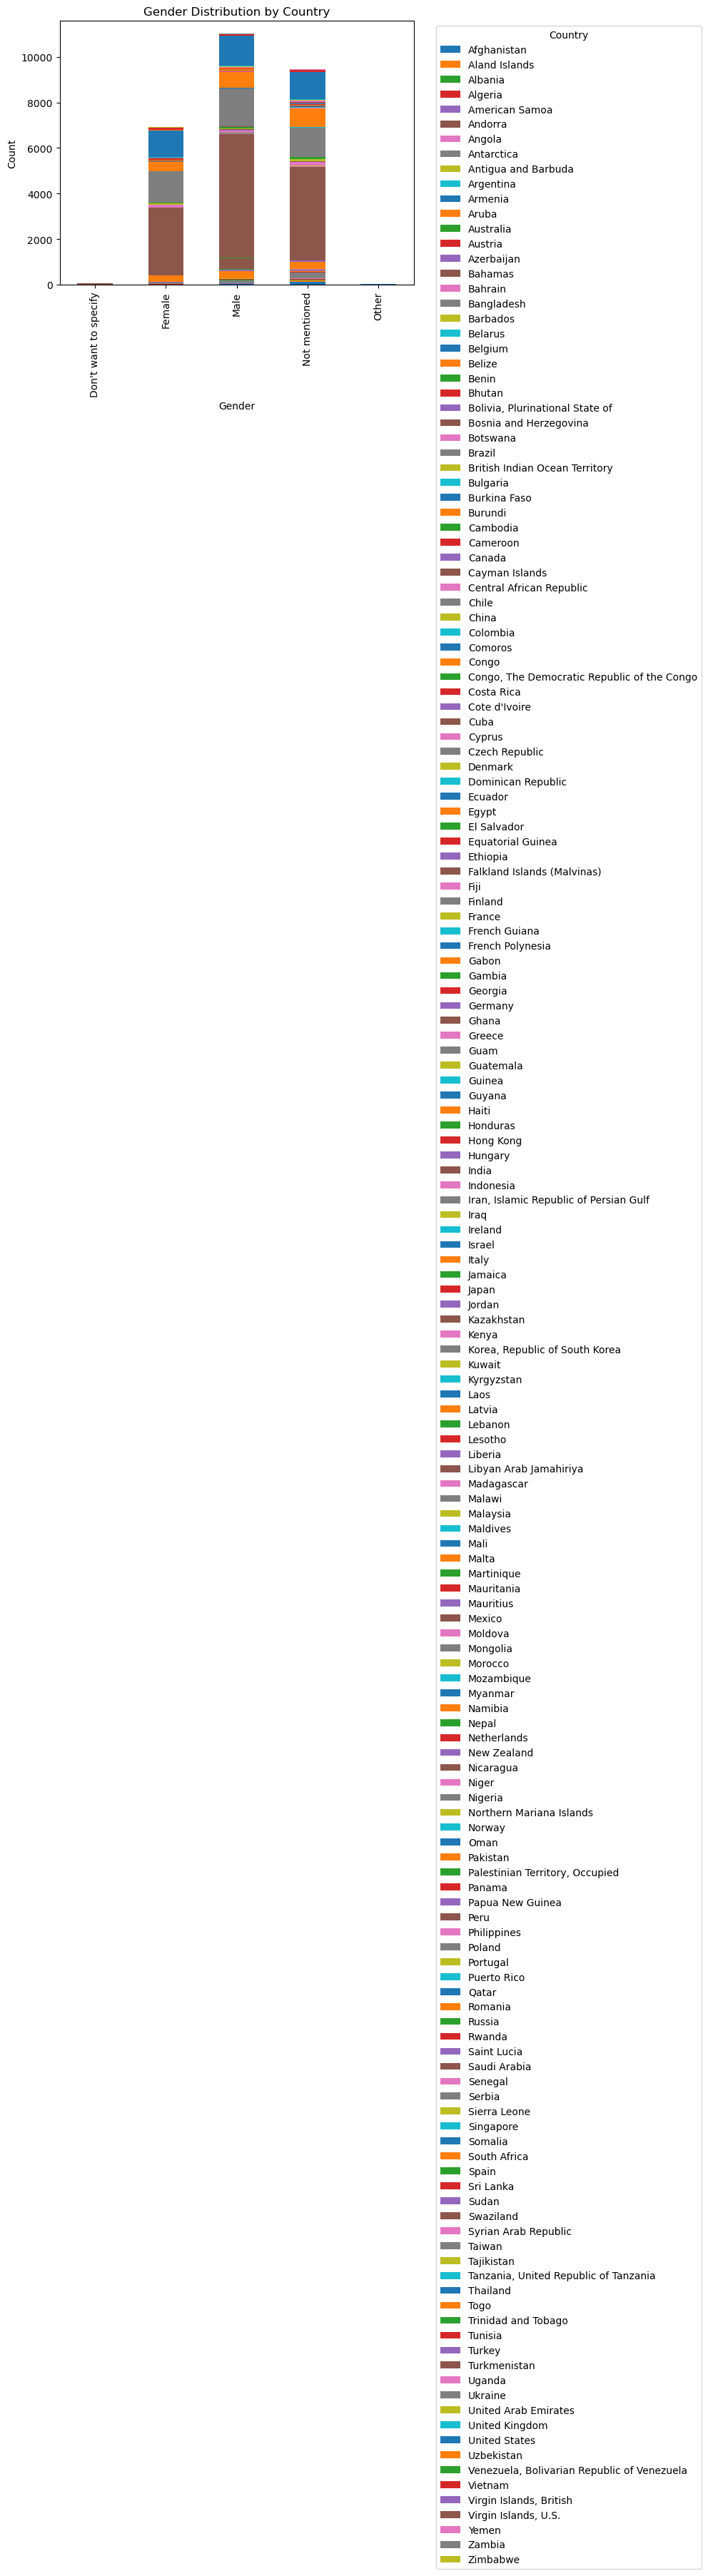

In [69]:
# Gender distribution by country
plt.figure(figsize=(12, 6))
gender_country = pd.crosstab(df['Gender'], df['Country'])
gender_country.plot(kind='bar', stacked=True)
plt.title('Gender Distribution by Country')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

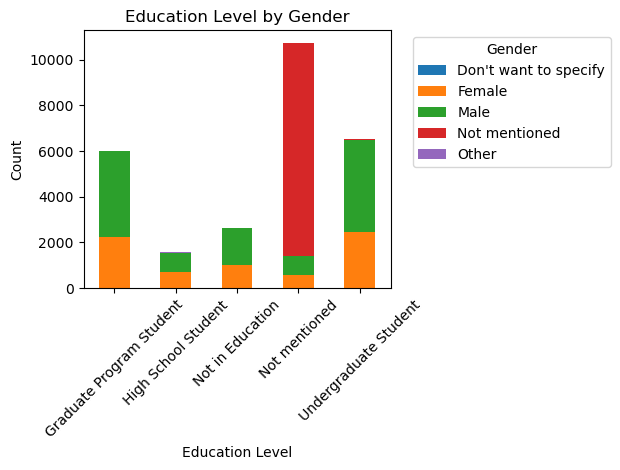

In [70]:
# Education level by gender
plt.figure(figsize=(12, 6))
education_gender = pd.crosstab(df['Degree'], df['Gender'])
education_gender.plot(kind='bar', stacked=True)
plt.title('Education Level by Gender')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()